### Importation of the libraries 

In [1]:
%%capture

%pip -q install numpy 
%pip -q install pandas 
%pip -q install matplotlib 
%pip -q install seaborn 
%pip -q install scikit-learn 
%pip -q install scikit-optimize 
%pip -q install xgboost
%pip -q install openpyxl
%pip -q install tabulate
%pip -q install statsmodels
%pip -q install shap

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import RepeatedStratifiedKFold
from skopt.space import Real, Integer
from skopt import BayesSearchCV
from xgboost import XGBClassifier
import openpyxl

In [3]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning) # Ignore FutureWarnings from sklearn and other libraries

### Loading the Data

In [4]:
df = pd.read_excel("Pups_Analyse NTs_221124.xlsx", sheet_name="NT-R-stack")

<span style="font-weight: bold;"> With the info command I have information about the data structure, including the number of rows, colums, data types and non-null values for each variables</span>

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Projet                108 non-null    str    
 1   Cohort                108 non-null    str    
 2   Group                 108 non-null    str    
 3   Cage                  60 non-null     str    
 4   ID                    81 non-null     object 
 5   ID.2                  81 non-null     object 
 6   Sample Name           108 non-null    str    
 7   Sex                   108 non-null    str    
 8   Area                  108 non-null    str    
 9   5HTP                  101 non-null    float64
 10  Adénosine             108 non-null    float64
 11  Adrénaline            3 non-null      float64
 12  Dopamine              67 non-null     float64
 13  GABA                  108 non-null    float64
 14  Glutamate             108 non-null    float64
 15  Glutamine aire brute  108 non-null

## Cleaning / Preparation / Visualisation of the Data

### Cleaning the Data 

<span style="font-weight: bold;"> We decided that any data that have a : </span>  
<span style="color:red"> - Tyrosine value inferior to 15 </span>  
<span style="color:red"> - Tyramine value superior to 40 </span>  
<span style="font-weight: bold;"> are considered as outliers: </span>

<span style="font-weight: bold;"> Here's a representation of these outliers </span>

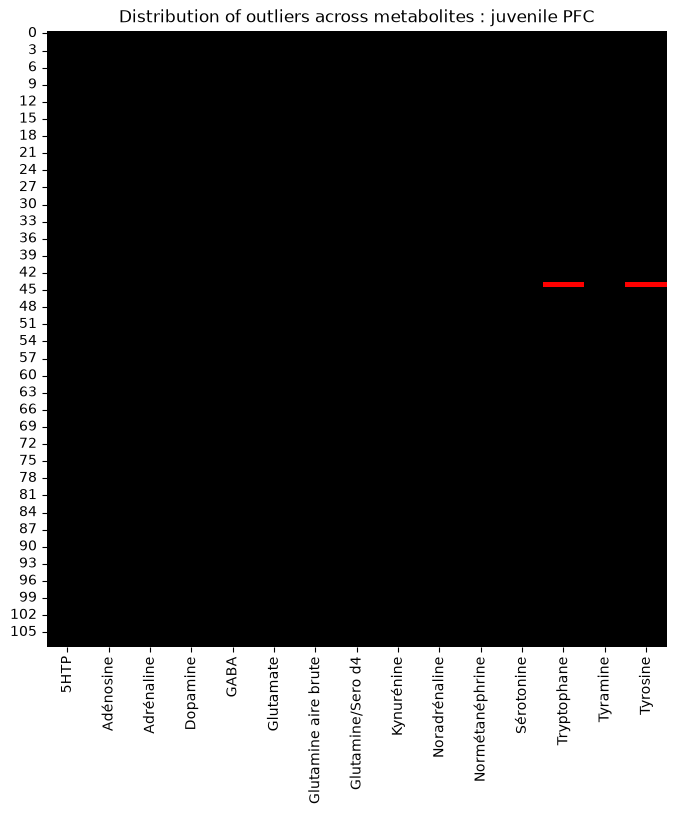

In [6]:
mask = (df["Tryptophane"] < 15) & (df["Tyrosine"] > 40)

outlier_mask = pd.DataFrame(False, index=df.index, columns=df.columns)
outlier_mask.loc[mask, ["Tryptophane", "Tyrosine"]] = True

nts = [
    "5HTP",
    "Adénosine",
    "Adrénaline",
    "Dopamine",
    "GABA",
    "Glutamate",
    "Glutamine aire brute",
    "Glutamine/Sero d4",
    "Kynurénine",
    "Noradrénaline",
    "Normétanéphrine",
    "Sérotonine",
    "Tryptophane",
    "Tyramine",
    "Tyrosine"
]

plt.figure(figsize=(8, 8))
sns.heatmap(
    outlier_mask[nts],
    #linewidths=0.05,
    cmap=["black", "red"],
    cbar=False
)
plt.title("Distribution of outliers across metabolites : juvenile PFC")
plt.show()

<span style="font-weight: bold;"> For more information about that outlier  </span>

In [7]:
print(df.loc[mask])

   Projet    Cohort Group Cage ID ID.2    Sample Name     Sex Area  5HTP  ...  \
44  VEAVE  Cohort 1   LBN    C  5   C5  Souris_LBN C5  female  STR   NaN  ...   

    Glutamate  Glutamine aire brute  Glutamine/Sero d4  Kynurénine  \
44      2.564              42760000              138.4    0.000186   

    Noradrénaline  Normétanéphrine  Sérotonine  Tryptophane  Tyramine  \
44         0.1161           0.1624      0.1014        9.042    0.1323   

    Tyrosine  
44     40.78  

[1 rows x 24 columns]


<span style="font-weight: bold;"> Now we remove that value </span>

In [8]:
df = df[
    ~(
        ((df['Tryptophane']<15) & (df['Tyrosine'] > 40))
    )
]
df = df.reset_index(drop=True) # Reset the index of the dataframe since we removed a row

<span style="font-weight: bold;"> So the different columns are : </span>

In [9]:
print(f"The columns in the dataset are: {df.columns}")

The columns in the dataset are: Index(['Projet', 'Cohort', 'Group', 'Cage', 'ID', 'ID.2', 'Sample Name', 'Sex',
       'Area', '5HTP', 'Adénosine', 'Adrénaline', 'Dopamine', 'GABA',
       'Glutamate', 'Glutamine aire brute', 'Glutamine/Sero d4', 'Kynurénine',
       'Noradrénaline', 'Normétanéphrine', 'Sérotonine', 'Tryptophane',
       'Tyramine', 'Tyrosine'],
      dtype='str')


### Separation of the Data by Area

<span style="font-weight: bold;"> Here we separate the data into 3 dataset : For the PFC, HIP, STR </span>

In [10]:
NT_df_pfc_juv = df.query("Area == 'PFC'").copy()
NT_df_hip_juv = df.query("Area == 'HIP'").copy()
NT_df_str_juv = df.query("Area == 'STR'").copy()



In [11]:
NT_df_pfc_juv.index = NT_df_pfc_juv.index + 1 # So now the index starts at 1 instead of 0
NT_df_hip_juv.index = NT_df_hip_juv.index + 1 # So now the index starts at 1 instead of 0
NT_df_str_juv.index = NT_df_str_juv.index + 1 # So now the index starts at 1 instead of 0

<span style="font-weight: bold;"> Now, for the number of individuals in each group for each Area. </span>

In [12]:
print(f" --In the PFC group--:",NT_df_pfc_juv['Group'].value_counts())
print(f" --In the HIP group-- :",NT_df_hip_juv['Group'].value_counts())
print(f" --In the STR group-- :",NT_df_str_juv['Group'].value_counts())

 --In the PFC group--: Group
CONT    18
LBN     15
Name: count, dtype: int64
 --In the HIP group-- : Group
LBN     21
CONT    21
Name: count, dtype: int64
 --In the STR group-- : Group
CONT    18
LBN     14
Name: count, dtype: int64


<span style="font-weight: bold;"> Now, the count of individuals broken down by sex cohort and cage, per area. </span>

#### For the PFC 

In [13]:
print("For the PFC Area : ")
print(
    NT_df_pfc_juv
    .groupby(['Group', 'Sex', 'Cohort', 'Cage'], dropna=False)
    .size()
    .reset_index(name='N')
)

For the PFC Area : 
   Group     Sex    Cohort Cage  N
0   CONT  female  Cohort 1    D  3
1   CONT  female  Cohort 2  NaN  1
2   CONT  female    July24  NaN  4
3   CONT    male  Cohort 1    D  2
4   CONT    male  Cohort 2  NaN  3
5   CONT    male    July24  NaN  5
6    LBN  female  Cohort 1    A  1
7    LBN  female  Cohort 1    C  5
8    LBN  female  Cohort 2  NaN  2
9    LBN    male  Cohort 1    A  6
10   LBN    male  Cohort 2  NaN  1



#### For the HIP

In [14]:
print("\nFor the HIP Area :")
print(
    NT_df_hip_juv
    .groupby(['Group', 'Sex', 'Cohort', 'Cage'], dropna=False)
    .size()
    .reset_index(name='N')
)


For the HIP Area :
   Group     Sex    Cohort Cage  N
0   CONT  female  Cohort 0    E  2
1   CONT  female  Cohort 1    D  3
2   CONT  female  Cohort 2  NaN  1
3   CONT  female    July24  NaN  4
4   CONT    male  Cohort 0    E  1
5   CONT    male  Cohort 1    D  2
6   CONT    male  Cohort 2  NaN  3
7   CONT    male    July24  NaN  5
8    LBN  female  Cohort 0    G  3
9    LBN  female  Cohort 1    A  1
10   LBN  female  Cohort 1    C  5
11   LBN  female  Cohort 2  NaN  2
12   LBN    male  Cohort 0    G  3
13   LBN    male  Cohort 1    A  6
14   LBN    male  Cohort 2  NaN  1


#### For the STR

In [15]:
print("\nFor the STR Area :")
print(
    NT_df_str_juv
    .groupby(['Group', 'Sex', 'Cohort', 'Cage'], dropna=False)
    .size()
    .reset_index(name='N')
)


For the STR Area :
   Group     Sex    Cohort Cage  N
0   CONT  female  Cohort 1    D  3
1   CONT  female  Cohort 2  NaN  1
2   CONT  female    July24  NaN  4
3   CONT    male  Cohort 1    D  2
4   CONT    male  Cohort 2  NaN  3
5   CONT    male    July24  NaN  5
6    LBN  female  Cohort 1    A  1
7    LBN  female  Cohort 1    C  4
8    LBN  female  Cohort 2  NaN  2
9    LBN    male  Cohort 1    A  6
10   LBN    male  Cohort 2  NaN  1


### Separation of the Data into 2 Dataset : X (Predictors : Variables - NTS ) and Y (Outcome : Group - LBN vs CONT)

In [16]:
columns_to_drop = ['Projet','Cohort','Group','Cage','ID','ID.2','Sample Name','Sex','Area','Dopamine','Adrénaline','Glutamine aire brute']
X_juv_pfc = NT_df_pfc_juv.drop(columns=columns_to_drop)
Y_juv_pfc = NT_df_pfc_juv['Group'].replace({'CONT': 0, 'LBN': 1}).astype(int)
X_juv_hip = NT_df_hip_juv.drop(columns=columns_to_drop)
Y_juv_hip = NT_df_hip_juv['Group'].replace({'CONT': 0, 'LBN': 1}).astype(int)
X_juv_str = NT_df_str_juv.drop(columns=columns_to_drop)
Y_juv_str = NT_df_str_juv['Group'].replace({'CONT': 0, 'LBN': 1}).astype(int)

### Visualisation of the missing values.

<span style="font-weight: bold;"> Here's a representation of these missing values </span>

--- 

#### For the PFC

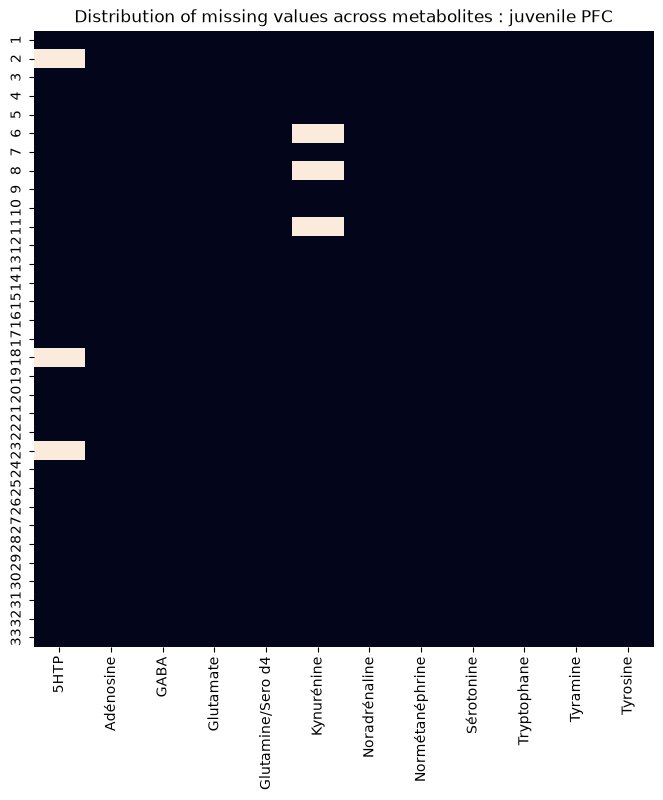

In [17]:
plt.figure(figsize=(8, 8))
sns.heatmap(X_juv_pfc.isna(), cbar=False)
plt.title("Distribution of missing values across metabolites : juvenile PFC")
plt.show()

In [18]:
print("Information about the Individuals who have missing values : PFC juv")
print(X_juv_pfc[X_juv_pfc.isna().any(axis=1)].to_markdown())


Information about the Individuals who have missing values : PFC juv
|    |      5HTP |   Adénosine |   GABA |   Glutamate |   Glutamine/Sero d4 |   Kynurénine |   Noradrénaline |   Normétanéphrine |   Sérotonine |   Tryptophane |   Tyramine |   Tyrosine |
|---:|----------:|------------:|-------:|------------:|--------------------:|-------------:|----------------:|------------------:|-------------:|--------------:|-----------:|-----------:|
|  2 | nan       |     0.114   |  4.946 |       3.372 |              353.2  |    0.000348  |          0.4457 |            1.248  |      0.2482  |        1.621  |    0.02929 |      9.92  |
|  6 |   0.07679 |     0.06489 |  4.35  |       3.066 |               26.69 |  nan         |          0.4418 |            0.866  |      0.2674  |        0.7045 |    0.08121 |      5.788 |
|  8 |   0.05436 |     0.04628 |  2.341 |       1.479 |               14.08 |  nan         |          0.2165 |            0.4885 |      0.09258 |        0.448  |    0.0355  |      

<span style="font-weight: bold;"> Now we will create a copy of the juvenile PFC dataset and add experimental groups ("CONT" and "LBN")</span>

In [19]:
X_juv_pfc_with_group = X_juv_pfc.copy()
X_juv_pfc_with_group["Group"] = Y_juv_pfc.map({0: "CONT", 1: "LBN"})
X_juv_pfc_with_group.head()

,5HTP,Adénosine,GABA,Glutamate,Glutamine/Sero d4,Kynurénine,Noradrénaline,Normétanéphrine,Sérotonine,Tryptophane,Tyramine,Tyrosine,Group
1,0.07121,0.1205,5.705,5.624,115.70,0.000358,0.5434,1.1470,0.1690,17.2300,0.12430,72.290,LBN
2,NaN,0.1140,4.946,3.372,353.20,0.000348,0.4457,1.2480,0.2482,1.6210,0.02929,9.920,LBN
3,0.09554,0.2878,4.199,3.240,61.33,0.000197,0.4152,0.7497,0.2027,0.6687,0.02476,5.434,LBN
4,0.07400,0.1642,4.777,3.392,83.70,0.000197,0.3339,1.3270,0.1919,0.8614,0.08478,5.847,LBN
5,0.06886,0.1563,4.204,3.150,81.44,0.000172,0.4195,0.7535,0.1023,0.9502,0.02396,6.285,LBN


---

#### For the HIP

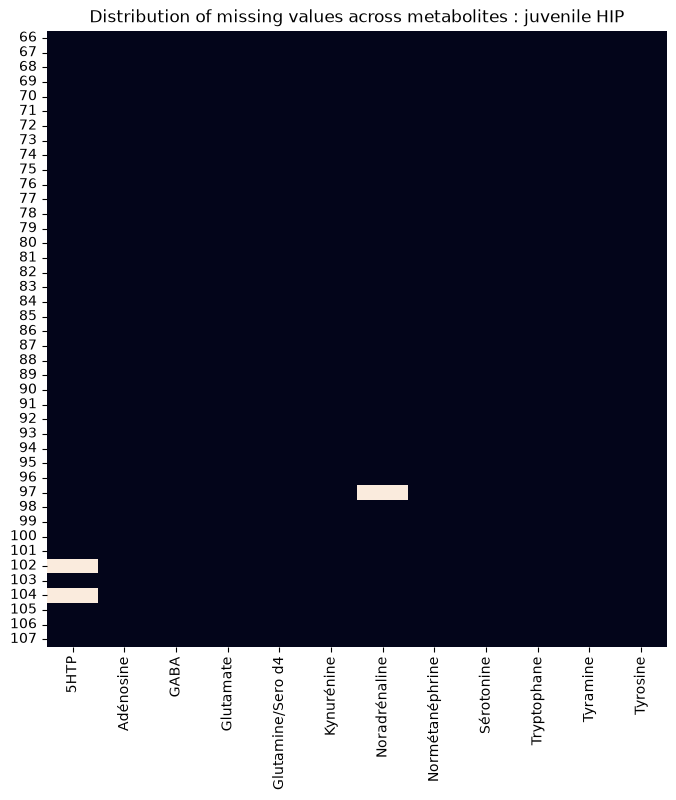

In [20]:
plt.figure(figsize=(8, 8))
sns.heatmap(X_juv_hip.isna(), cbar=False)
plt.title("Distribution of missing values across metabolites : juvenile HIP")
plt.show()

In [21]:
print("Information about the Individuals who have missing values : HIP juv")
print(X_juv_hip[X_juv_hip.isna().any(axis=1)].to_markdown())


Information about the Individuals who have missing values : HIP juv
|     |      5HTP |   Adénosine |   GABA |   Glutamate |   Glutamine/Sero d4 |   Kynurénine |   Noradrénaline |   Normétanéphrine |   Sérotonine |   Tryptophane |   Tyramine |   Tyrosine |
|----:|----------:|------------:|-------:|------------:|--------------------:|-------------:|----------------:|------------------:|-------------:|--------------:|-----------:|-----------:|
|  97 |   0.03652 |      0.1513 |  4.149 |       2.817 |              209.8  |    0.0003631 |        nan      |            0.9053 |       0.1095 |        3.502  |     0.2702 |     17.31  |
| 102 | nan       |      0.3103 |  4.02  |       2.682 |               84.33 |    0.0003547 |          0.312  |            0.7644 |       0.2293 |        0.7045 |     0.3007 |      5.821 |
| 104 | nan       |      0.1994 |  3.526 |       2.275 |               91.51 |    0.0002266 |          0.2811 |            0.6544 |       0.2525 |        5.527  |     0.2244 | 

<span style="font-weight: bold;"> Now we will create a copy of the juvenile HIP dataset and add experimental groups ("CONT" and "LBN")</span>

In [22]:
X_juv_hip_with_group = X_juv_hip.copy()
X_juv_hip_with_group["Group"] = Y_juv_hip.map({0: "CONT", 1: "LBN"})
X_juv_hip_with_group.head()

,5HTP,Adénosine,GABA,Glutamate,Glutamine/Sero d4,Kynurénine,Noradrénaline,Normétanéphrine,Sérotonine,Tryptophane,Tyramine,Tyrosine,Group
66,0.16110,0.1061,5.316,3.774,459.1,0.000304,0.5380,0.6292,0.3534,2.560,0.05877,10.990,LBN
67,0.04372,0.1037,5.288,3.645,111.6,0.000386,0.5103,0.8059,0.2138,1.354,0.02393,7.273,LBN
68,0.17180,0.2305,6.150,4.494,507.8,0.000291,0.5944,0.8248,0.4750,1.920,0.02132,9.272,LBN
69,0.14740,0.2582,6.843,5.044,571.3,0.000312,0.5672,1.0550,0.4088,7.368,0.02837,18.700,LBN
70,0.15700,0.2091,5.723,4.118,380.8,0.000209,0.5549,0.5001,0.4062,3.666,0.02336,15.970,LBN


---

#### For the STR

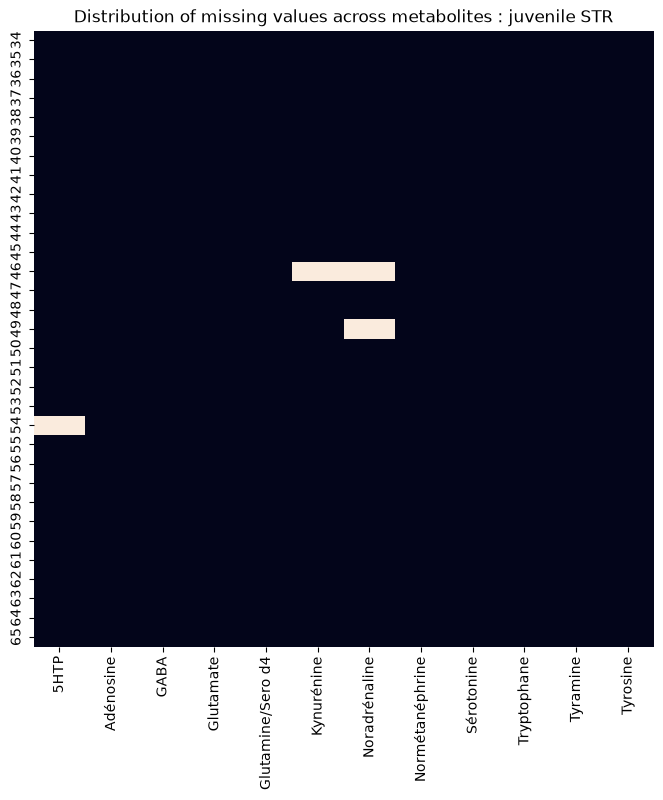

In [23]:
plt.figure(figsize=(8, 8))
sns.heatmap(X_juv_str.isna(), cbar=False)
plt.title("Distribution of missing values across metabolites : juvenile STR")
plt.show()

In [24]:
print("Information about the Individuals who have missing values : STR juv")
print(X_juv_str[X_juv_str.isna().any(axis=1)].to_markdown())

Information about the Individuals who have missing values : STR juv
|    |      5HTP |   Adénosine |   GABA |   Glutamate |   Glutamine/Sero d4 |   Kynurénine |   Noradrénaline |   Normétanéphrine |   Sérotonine |   Tryptophane |   Tyramine |   Tyrosine |
|---:|----------:|------------:|-------:|------------:|--------------------:|-------------:|----------------:|------------------:|-------------:|--------------:|-----------:|-----------:|
| 46 |   0.05638 |      0.6234 |  3.645 |       2.412 |               37.69 |  nan         |       nan       |            0.2305 |       0.2553 |         1.509 |    0.1939  |      5.732 |
| 49 |   0.04216 |      0.5245 |  3.43  |       2.452 |               38.49 |    9.549e-05 |       nan       |            0.2024 |       0.134  |         1.583 |    0.09083 |      7.25  |
| 54 | nan       |      2.587  |  7.975 |       3.185 |              164.7  |    0.0002746 |         0.09882 |            0.3882 |       0.2074 |         2.63  |    0.2646  |      

<span style="font-weight: bold;"> Now we will create a copy of the juvenile STR dataset and add experimental groups ("CONT" and "LBN")</span>

In [25]:
X_juv_str_with_group = X_juv_str.copy()
X_juv_str_with_group["Group"] = Y_juv_str.map({0: "CONT", 1: "LBN"})
X_juv_str_with_group.head()

,5HTP,Adénosine,GABA,Glutamate,Glutamine/Sero d4,Kynurénine,Noradrénaline,Normétanéphrine,Sérotonine,Tryptophane,Tyramine,Tyrosine,Group
34,0.15510,0.4607,8.217,4.325,217.10,0.000358,0.7035,0.3851,0.2305,1.3440,0.18670,9.593,LBN
35,0.12050,0.6893,4.277,4.705,510.40,0.000413,0.1120,0.2321,0.1860,3.7550,0.17590,28.770,LBN
36,0.13190,0.7967,8.135,3.710,82.61,0.000305,0.8191,0.3697,0.6090,0.8823,0.10010,7.236,LBN
37,0.28870,0.7879,8.587,3.302,525.90,0.000302,0.6250,0.4807,0.3300,1.3680,0.08390,9.025,LBN
38,0.08625,0.4957,6.949,3.710,71.17,0.000232,0.7227,0.3707,0.4726,1.0300,0.08277,8.320,LBN


#### Transformation Log 

<span style="font-weight: bold;"> Apply a log(1+x) transformation to reduce skewness </span>


In [26]:
X_juv_pfc_log = np.log1p(X_juv_pfc)
X_juv_hip_log = np.log1p(X_juv_hip)
X_juv_str_log = np.log1p(X_juv_str)

## Analysis

### Principal Component Analysis (PCA)

---

#### For the PFC

<span style="font-weight: bold;"> Missing values were imputed using the median value of each metabolite, followed by z-score normalization to center and scale all features prior to analysis.

In [27]:
imputer = SimpleImputer(strategy="median")
X_juv_pfc_imp = imputer.fit_transform(X_juv_pfc_log)
scaler = StandardScaler()
X_juv_pfc_scaled = scaler.fit_transform(X_juv_pfc_imp)

<span style="font-weight: bold;"> The values used for the imputation are : 

In [28]:
missing_cols = X_juv_pfc_log.columns[X_juv_pfc_log.isna().any()]
median_used = pd.Series(
    imputer.statistics_,
    index=X_juv_pfc_log.columns
).loc[missing_cols]

print(f"The Median values used for imputation:\n{median_used}")

The Median values used for imputation:
5HTP          0.062893
Kynurénine    0.000224
dtype: float64


<span style="font-weight: bold;">  Here we apply PCA to the standardized PFC dataset and retain the first 10 principal components to know more about the explained variance

In [29]:
from sklearn.decomposition import PCA
pca1 = PCA(n_components=10)
X_juv_pfc_scaled1 = X_juv_pfc_scaled.copy()
X_juv_pfc_pca_all = pca1.fit_transform(X_juv_pfc_scaled1)

<span style="font-weight: bold;">  Visualisation of the Variance explained by Each Principal Component. 

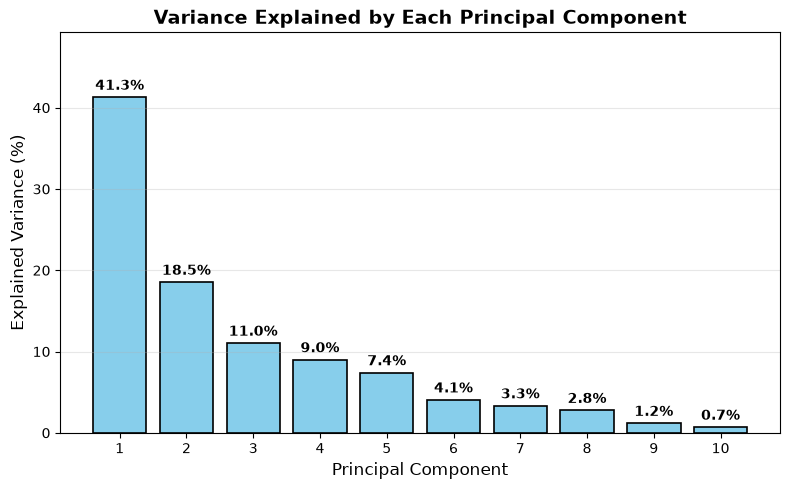

In [30]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Percentage of explained variance
explained = pca1.explained_variance_ratio_ * 100

# Create figure
plt.figure(figsize=(8, 5))

# Bar plot
bars = plt.bar(
    range(1, len(explained) + 1),
    explained,
    color="skyblue",
    edgecolor="black",
    linewidth=1.2
)

# Add percentage labels with black outline
for bar, value in zip(bars, explained):

    txt = plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


# Labels and title
plt.xlabel("Principal Component", fontsize=12)
plt.ylabel("Explained Variance (%)", fontsize=12)
plt.title(
    "Variance Explained by Each Principal Component",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(range(1, len(explained) + 1))
plt.ylim(0, max(explained) + 8)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

 <span style="font-weight: bold;"> Now to know how many Principal Components we need to obtain at least 80% of explained variance.

In [31]:
import numpy as np

for i in range(1, len(pca1.explained_variance_ratio_) + 1):
    x = np.sum(pca1.explained_variance_ratio_[:i])

    if x >= 0.8:
        print(f"To obtain at least 80% of the explained variance, {i} principal components are required which sum up to {x*100:.2f}%.")
        break

To obtain at least 80% of the explained variance, 5 principal components are required which sum up to 87.31%.


 <span style="font-weight: bold;">Here we apply PCA to the standardized PFC dataset and retain the first 3 principal components for our analysis

In [32]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_juv_pfc_pca = pca.fit_transform(X_juv_pfc_scaled)

In [33]:
print(f"The value of the PCA: \n PCA1 : {pca.explained_variance_ratio_[0]},\n PCA2 : {pca.explained_variance_ratio_[1]} \n PCA3 : {pca.explained_variance_ratio_[2]} ")
print(f"And the sum is:", pca.explained_variance_ratio_.sum())

The value of the PCA: 
 PCA1 : 0.4130362343470667,
 PCA2 : 0.18540285884753213 
 PCA3 : 0.11045194762258333 
And the sum is: 0.7088910408171822


 <span style="font-weight: bold;"> Now to have a visualtion of the PCA projection of PFC samples on the first two principal components

findfont: Failed to find font weight semibold, now using 700.


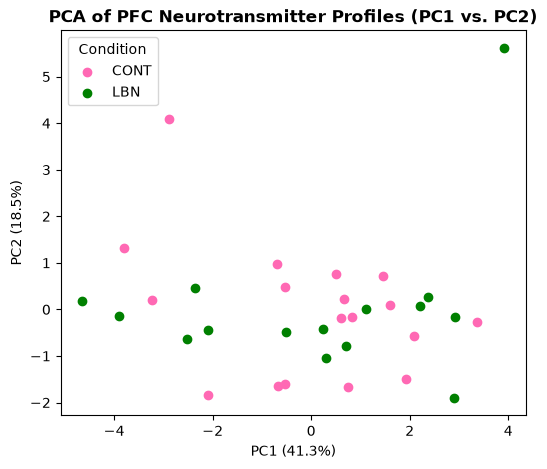

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    X_juv_pfc_pca[Y_juv_pfc == 0, 0],
    X_juv_pfc_pca[Y_juv_pfc == 0, 1],
    label="CONT",
    color="hotpink"
)

plt.scatter(
    X_juv_pfc_pca[Y_juv_pfc == 1, 0],
    X_juv_pfc_pca[Y_juv_pfc == 1, 1],
    label="LBN",
    color="green"
)

plt.title("PCA of PFC Neurotransmitter Profiles (PC1 vs. PC2)", fontweight='semibold')

plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"
)

plt.legend(title="Condition")
plt.show()

 <span style="font-weight: bold;"> Create a 3D PCA score plot with projection ("needle") lines extending from each sample to the base plane to facilitate the visualization of sample positions in three-dimensional space.

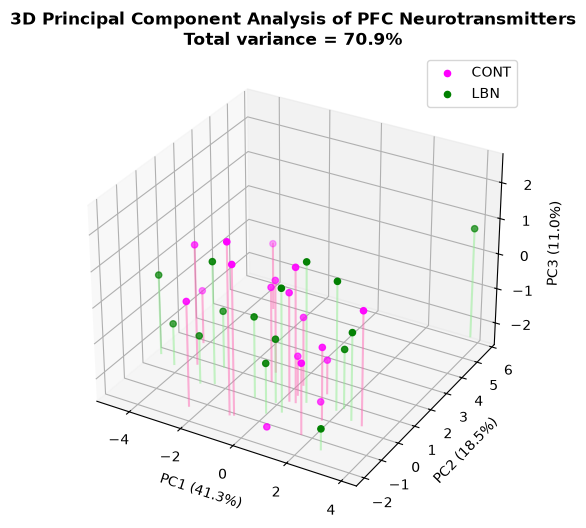

In [35]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

zmin = X_juv_pfc_pca[:,2].min() # here we define the minimum value of the z-axis to be used for the needle lines. This is set to the minimum value of the third principal component (PC3) in the PCA-transformed data.

# if you don't want the needle lines to the bottom of the plot, you can comment out these two lines
for x, y, z in X_juv_pfc_pca[Y_juv_pfc==0, :3]:
     ax.plot([x, x], [y, y], [zmin, z], color='hotpink', alpha=0.5)

ax.scatter(
    X_juv_pfc_pca[Y_juv_pfc==0,0],
    X_juv_pfc_pca[Y_juv_pfc==0,1],
    X_juv_pfc_pca[Y_juv_pfc==0,2],
    label="CONT",
    color='magenta'
)

# if you don't want the needle lines to the bottom of the plot, you can comment out these two lines
for x, y, z in X_juv_pfc_pca[Y_juv_pfc==1, :3]:
    ax.plot([x, x], [y, y], [zmin, z], color='lightgreen', alpha=0.5)

ax.scatter(
    X_juv_pfc_pca[Y_juv_pfc==1,0],
    X_juv_pfc_pca[Y_juv_pfc==1,1],
    X_juv_pfc_pca[Y_juv_pfc==1,2],
    label="LBN",
    color='green'
)

ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
ax.set_zlabel(f"PC3 ({100*pca.explained_variance_ratio_[2]:.1f}%)")

ax.set_title(
    f"3D Principal Component Analysis of PFC Neurotransmitters\n"
    f"Total variance = {100*sum(pca.explained_variance_ratio_[:3]):.1f}%",
    fontweight='semibold'
)

ax.legend()
plt.show()

 <span style="font-weight: bold;"> Now we will create a 3D PCA score plot of the PFC neurotransmitter data to visualize the distribution of samples from the CONT and LBN groups along the first three principal components.

findfont: Failed to find font weight semibold, now using 700.


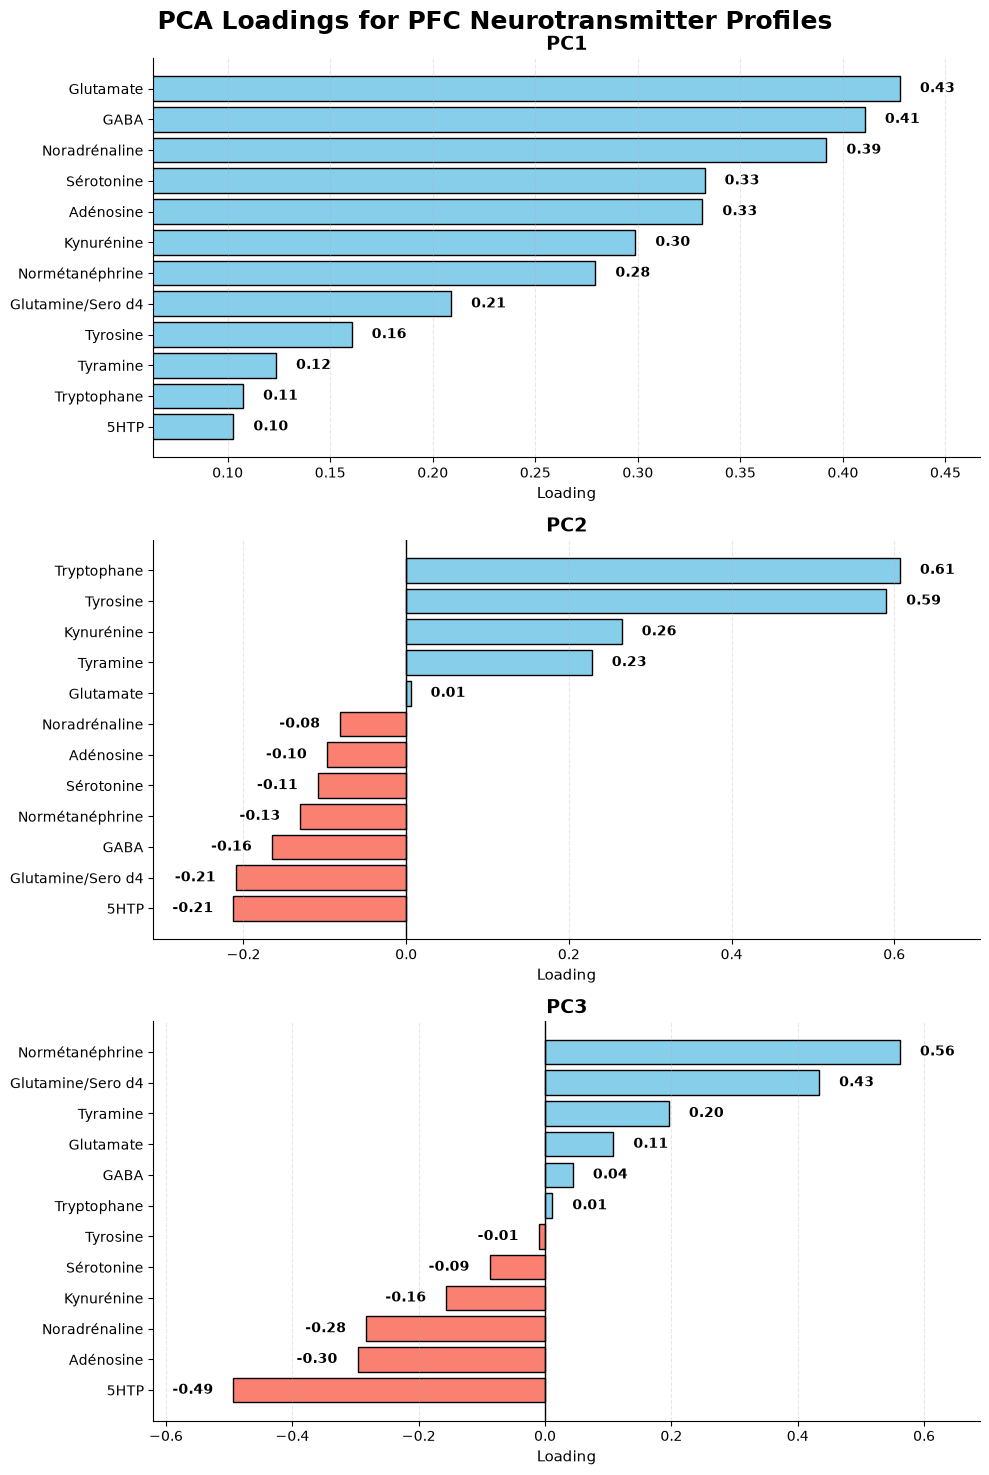

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# PCA loadings
loadings_pfc = pd.DataFrame(
    pca.components_.T,
    index=X_juv_pfc.columns,
    columns=["PC1", "PC2", "PC3"]
)

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

fig.suptitle(
    "PCA Loadings for PFC Neurotransmitter Profiles",fontsize=18, fontweight="semibold"
)

for i, pc in enumerate(loadings_pfc.columns):
    ax = axes[i]
    values = loadings_pfc[pc].sort_values()
    colors = [ "skyblue" if v >= 0 else "salmon" for v in values]

    bars = ax.barh(
        values.index,
        values.values,
        color=colors,
        edgecolor="black"
    )

    ax.axvline(
        0,
        color="black",
        linewidth=1
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_title(
        pc,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Loading",
        fontsize=11
    )

    xmin = values.min()
    xmax = values.max()
    offset = (xmax - xmin) * 0.03

    ax.set_xlim(xmin - 4*offset, xmax + 4*offset)

    for bar, value in zip(bars, values):

        if value >= 0:
            ax.text(
                value + offset,
                bar.get_y() + bar.get_height()/2,
                f"{value:.2f}",
                va="center",
                ha="left",
                fontsize=10,
                fontweight="bold"
            )
        else:
            ax.text(
                value - offset,
                bar.get_y() + bar.get_height()/2,
                f"{value:.2f}",
                va="center",
                ha="right",
                fontsize=10,
                fontweight="bold"
            )

plt.tight_layout()
plt.show()

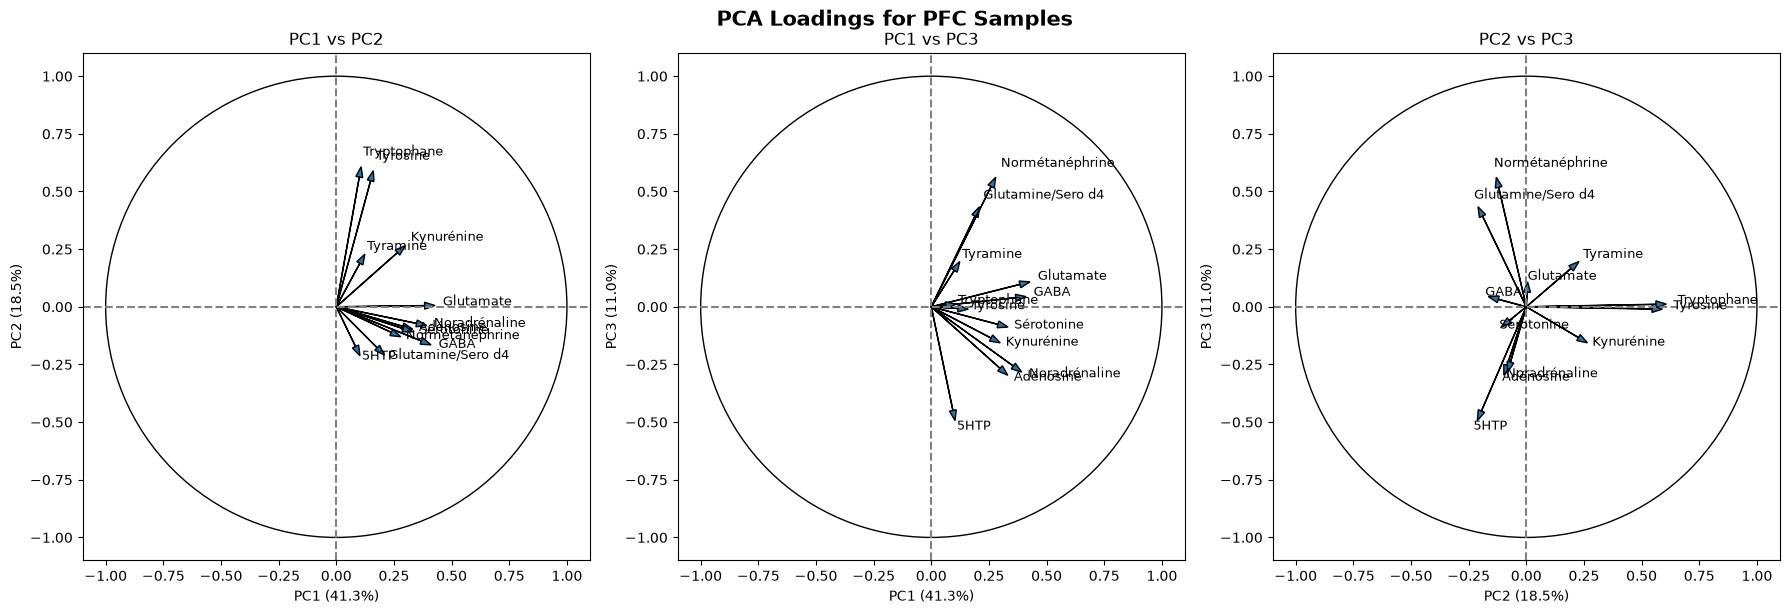

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

# Loadings
loadings_pfc = pd.DataFrame(
    pca.components_.T,
    index=X_juv_pfc.columns,
    columns=["PC1", "PC2", "PC3"]
)

pairs = [
    ("PC1", "PC2"),
    ("PC1", "PC3"),
    ("PC2", "PC3")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "PCA Loadings for PFC Samples",
    fontsize=15,
    fontweight="bold"
) 

for ax, (pcx, pcy) in zip(axes, pairs):

    # cercle
    circle = plt.Circle(
        (0, 0),
        1,
        fill=False,
        color="black"
    )
    ax.add_artist(circle)

    # flèches
    for nt in loadings_pfc.index:

        x = loadings_pfc.loc[nt, pcx]
        y = loadings_pfc.loc[nt, pcy]

        ax.arrow(
            0, 0,
            x, y,
            head_width=0.03,
            length_includes_head=True
        )

        ax.text(
            x*1.08,
            y*1.08,
            nt,
            fontsize=9
        )

    ax.axhline(0, color="grey", linestyle="--")
    ax.axvline(0, color="grey", linestyle="--")

    # Pourcentage expliqué
    pcx_num = int(pcx[-1]) - 1
    pcy_num = int(pcy[-1]) - 1

    ax.set_xlabel(
        f"{pcx} ({pca.explained_variance_ratio_[pcx_num]*100:.1f}%)"
    )

    ax.set_ylabel(
        f"{pcy} ({pca.explained_variance_ratio_[pcy_num]*100:.1f}%)"
    )

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")

    ax.set_title(f"{pcx} vs {pcy}")

plt.tight_layout()
plt.show()

---

#### For the HIP 

In [38]:
imputer = SimpleImputer(strategy="median")
X_juv_hip_imp = imputer.fit_transform(X_juv_hip_log)
scaler = StandardScaler()
X_juv_hip_scaled = scaler.fit_transform(X_juv_hip_imp)

In [39]:
missing_cols = X_juv_hip_log.columns[X_juv_hip_log.isna().any()]
median_used = pd.Series(
    imputer.statistics_,
    index=X_juv_hip_log.columns
).loc[missing_cols]

print(f"The Median values used for imputation:\n{median_used}")

The Median values used for imputation:
5HTP             0.056503
Noradrénaline    0.385194
dtype: float64


In [40]:
from sklearn.decomposition import PCA
pca1 = PCA(n_components=10)
X_juv_hip_scaled1 = X_juv_hip_scaled.copy()
X_juv_hip_pca_all = pca1.fit_transform(X_juv_hip_scaled1)

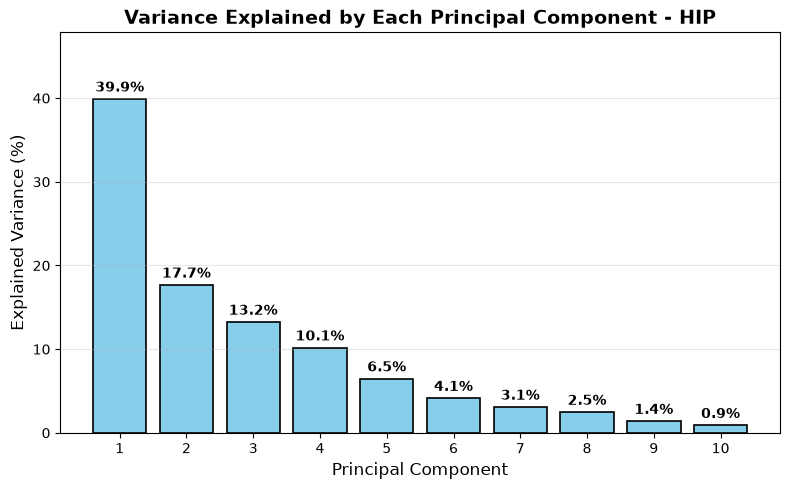

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Percentage of explained variance
explained = pca1.explained_variance_ratio_ * 100

# Create figure
plt.figure(figsize=(8, 5))

# Bar plot
bars = plt.bar(
    range(1, len(explained) + 1),
    explained,
    color="skyblue",
    edgecolor="black",
    linewidth=1.2
)

# Add percentage labels with black outline
for bar, value in zip(bars, explained):

    txt = plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


# Labels and title
plt.xlabel("Principal Component", fontsize=12)
plt.ylabel("Explained Variance (%)", fontsize=12)
plt.title(
    "Variance Explained by Each Principal Component - HIP",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(range(1, len(explained) + 1))
plt.ylim(0, max(explained) + 8)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

In [42]:
import numpy as np

for i in range(1, len(pca1.explained_variance_ratio_) + 1):
    x = np.sum(pca1.explained_variance_ratio_[:i])

    if x >= 0.8:
        print(f"To obtain at least 80% of the explained variance, {i} principal components are required which sum up to {x*100:.2f}%.")
        break

To obtain at least 80% of the explained variance, 4 principal components are required which sum up to 80.91%.


In [43]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_juv_hip_pca = pca.fit_transform(X_juv_hip_scaled)

In [44]:
print(f"The value of the PCA: \n PCA1 : {pca.explained_variance_ratio_[0]},\n PCA2 : {pca.explained_variance_ratio_[1]} \n PCA3 : {pca.explained_variance_ratio_[2]} ")
print(f"And the sum is:", pca.explained_variance_ratio_.sum())

The value of the PCA: 
 PCA1 : 0.39891286855956976,
 PCA2 : 0.17653186709763227 
 PCA3 : 0.13221243840745986 
And the sum is: 0.7076571740646619


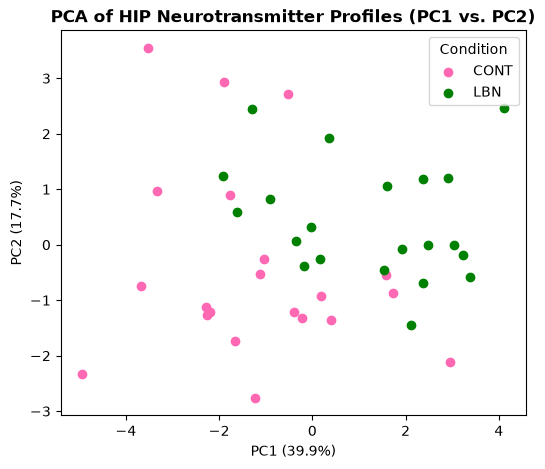

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    X_juv_hip_pca[Y_juv_hip == 0, 0],
    X_juv_hip_pca[Y_juv_hip == 0, 1],
    label="CONT",
    color="hotpink"
)

plt.scatter(
    X_juv_hip_pca[Y_juv_hip == 1, 0],
    X_juv_hip_pca[Y_juv_hip == 1, 1],
    label="LBN",
    color="green"
)

plt.title("PCA of HIP Neurotransmitter Profiles (PC1 vs. PC2)", fontweight='semibold')

plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"
)

plt.legend(title="Condition")
plt.show()

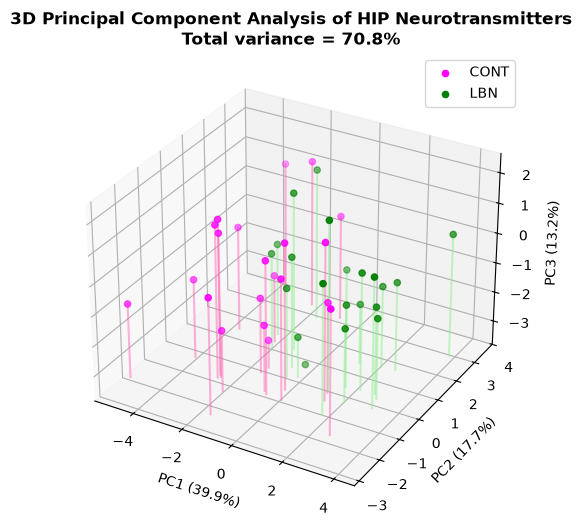

In [46]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

zmin = X_juv_hip_pca[:,2].min() # here we define the minimum value of the z-axis to be used for the needle lines. This is set to the minimum value of the third principal component (PC3) in the PCA-transformed data.

# if you don't want the needle lines to the bottom of the plot, you can comment out these two lines
for x, y, z in X_juv_hip_pca[Y_juv_hip==0, :3]:
     ax.plot([x, x], [y, y], [zmin, z], color='hotpink', alpha=0.5)

ax.scatter(
    X_juv_hip_pca[Y_juv_hip==0,0],
    X_juv_hip_pca[Y_juv_hip==0,1],
    X_juv_hip_pca[Y_juv_hip==0,2],
    label="CONT",
    color='magenta'
)

# if you don't want the needle lines to the bottom of the plot, you can comment out these two lines
for x, y, z in X_juv_hip_pca[Y_juv_hip==1, :3]:
    ax.plot([x, x], [y, y], [zmin, z], color='lightgreen', alpha=0.5)

ax.scatter(
    X_juv_hip_pca[Y_juv_hip==1,0],
    X_juv_hip_pca[Y_juv_hip==1,1],
    X_juv_hip_pca[Y_juv_hip==1,2],
    label="LBN",
    color='green'
)

ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
ax.set_zlabel(f"PC3 ({100*pca.explained_variance_ratio_[2]:.1f}%)")

ax.set_title(
    f"3D Principal Component Analysis of HIP Neurotransmitters\n"
    f"Total variance = {100*sum(pca.explained_variance_ratio_[:3]):.1f}%",
    fontweight='semibold'
)

ax.legend()
plt.show()

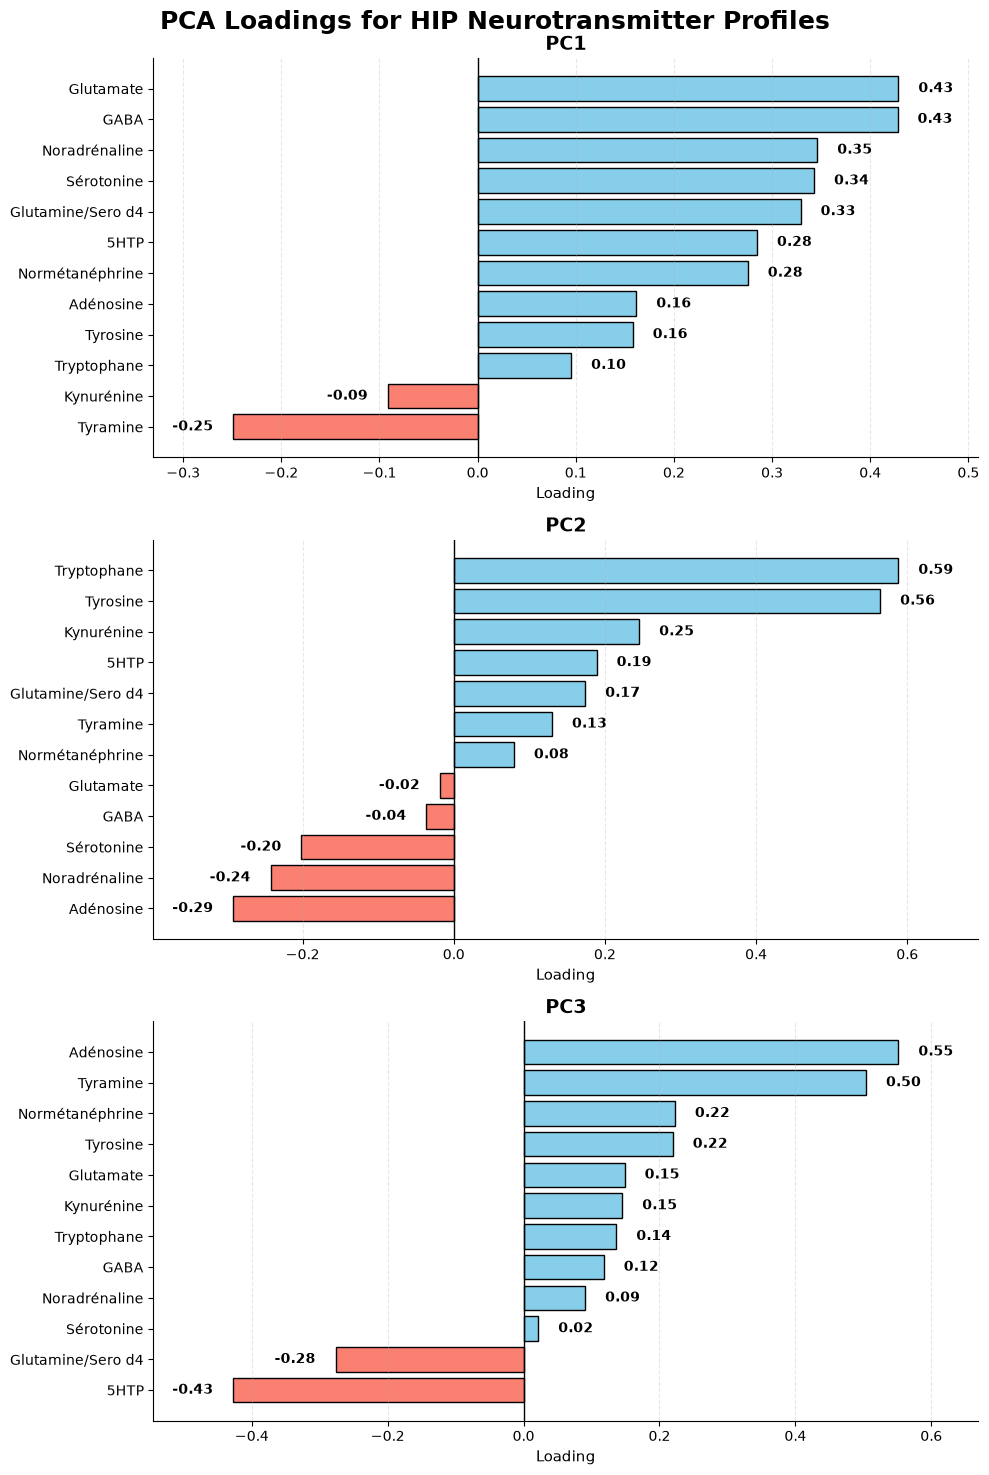

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# PCA loadings
loadings_hip = pd.DataFrame(
    pca.components_.T,
    index=X_juv_hip.columns,
    columns=["PC1", "PC2", "PC3"]
)

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

fig.suptitle(
    "PCA Loadings for HIP Neurotransmitter Profiles",fontsize=18, fontweight="semibold"
)

for i, pc in enumerate(loadings_hip.columns):
    ax = axes[i]
    values = loadings_hip[pc].sort_values()
    colors = [ "skyblue" if v >= 0 else "salmon" for v in values]

    bars = ax.barh(
        values.index,
        values.values,
        color=colors,
        edgecolor="black"
    )

    ax.axvline(
        0,
        color="black",
        linewidth=1
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_title(
        pc,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Loading",
        fontsize=11
    )

    xmin = values.min()
    xmax = values.max()
    offset = (xmax - xmin) * 0.03

    ax.set_xlim(xmin - 4*offset, xmax + 4*offset)

    for bar, value in zip(bars, values):

        if value >= 0:
            ax.text(
                value + offset,
                bar.get_y() + bar.get_height()/2,
                f"{value:.2f}",
                va="center",
                ha="left",
                fontsize=10,
                fontweight="bold"
            )
        else:
            ax.text(
                value - offset,
                bar.get_y() + bar.get_height()/2,
                f"{value:.2f}",
                va="center",
                ha="right",
                fontsize=10,
                fontweight="bold"
            )

plt.tight_layout()
plt.show()

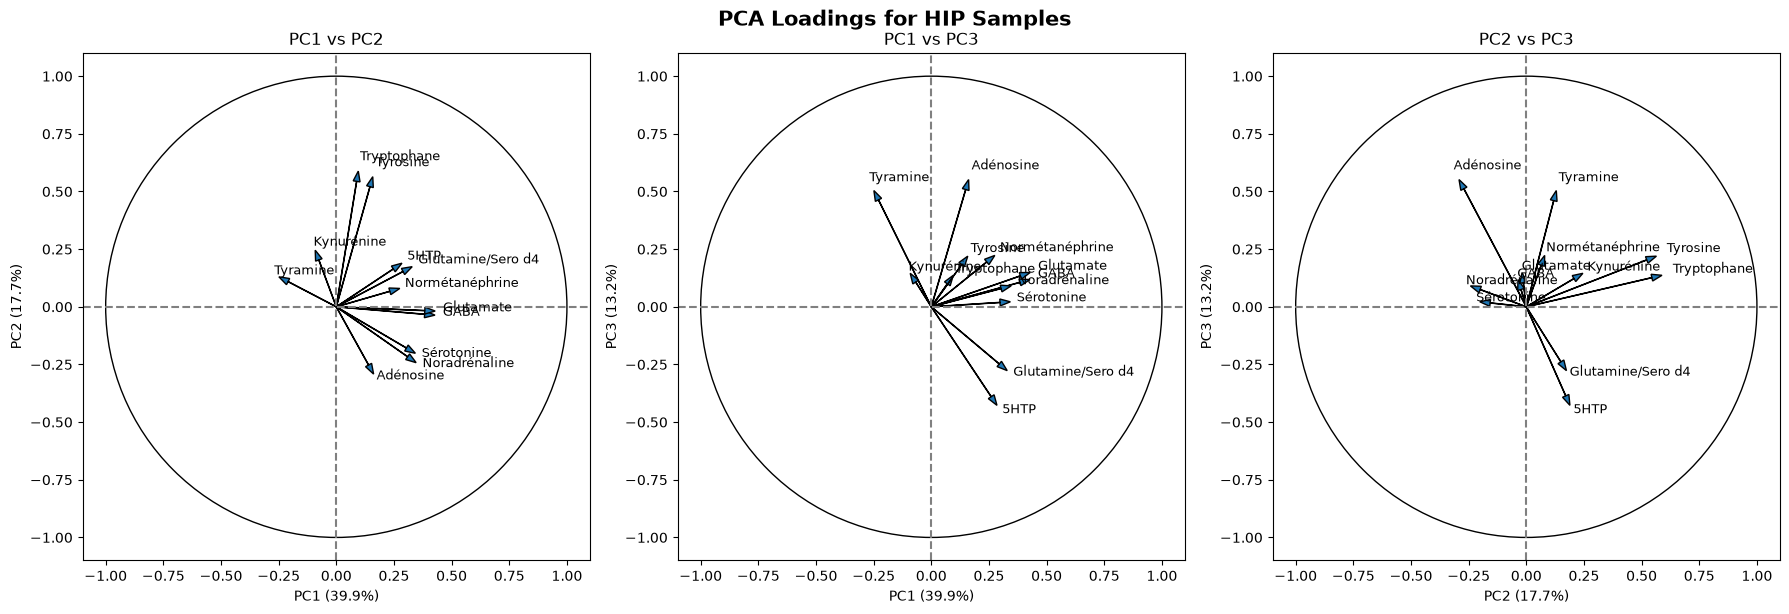

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

# Loadings
loadings_hip = pd.DataFrame(
    pca.components_.T,
    index=X_juv_hip.columns,
    columns=["PC1", "PC2", "PC3"]
)

pairs = [
    ("PC1", "PC2"),
    ("PC1", "PC3"),
    ("PC2", "PC3")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "PCA Loadings for HIP Samples",
    fontsize=15,
    fontweight="bold"
) 

for ax, (pcx, pcy) in zip(axes, pairs):

    # cercle
    circle = plt.Circle(
        (0, 0),
        1,
        fill=False,
        color="black"
    )
    ax.add_artist(circle)

    # flèches
    for nt in loadings_hip.index:

        x = loadings_hip.loc[nt, pcx]
        y = loadings_hip.loc[nt, pcy]

        ax.arrow(
            0, 0,
            x, y,
            head_width=0.03,
            length_includes_head=True
        )

        ax.text(
            x*1.08,
            y*1.08,
            nt,
            fontsize=9
        )

    ax.axhline(0, color="grey", linestyle="--")
    ax.axvline(0, color="grey", linestyle="--")

    # Pourcentage expliqué
    pcx_num = int(pcx[-1]) - 1
    pcy_num = int(pcy[-1]) - 1

    ax.set_xlabel(
        f"{pcx} ({pca.explained_variance_ratio_[pcx_num]*100:.1f}%)"
    )

    ax.set_ylabel(
        f"{pcy} ({pca.explained_variance_ratio_[pcy_num]*100:.1f}%)"
    )

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")

    ax.set_title(f"{pcx} vs {pcy}")

plt.tight_layout()
plt.show()

---

#### For the STR

In [49]:
imputer = SimpleImputer(strategy="median")
X_juv_str_imp = imputer.fit_transform(X_juv_str_log)
scaler = StandardScaler()
X_juv_str_scaled = scaler.fit_transform(X_juv_str_imp)

In [50]:
missing_cols = X_juv_str_log.columns[X_juv_str_log.isna().any()]
median_used = pd.Series(
    imputer.statistics_,
    index=X_juv_str_log.columns
).loc[missing_cols]

print(f"The Median values used for imputation:\n{median_used}")

The Median values used for imputation:
5HTP             0.099302
Kynurénine       0.000239
Noradrénaline    0.370767
dtype: float64


In [51]:
from sklearn.decomposition import PCA
pca1 = PCA(n_components=10)
X_juv_str_scaled1 = X_juv_str_scaled.copy()
X_juv_str_pca_all = pca1.fit_transform(X_juv_str_scaled1)

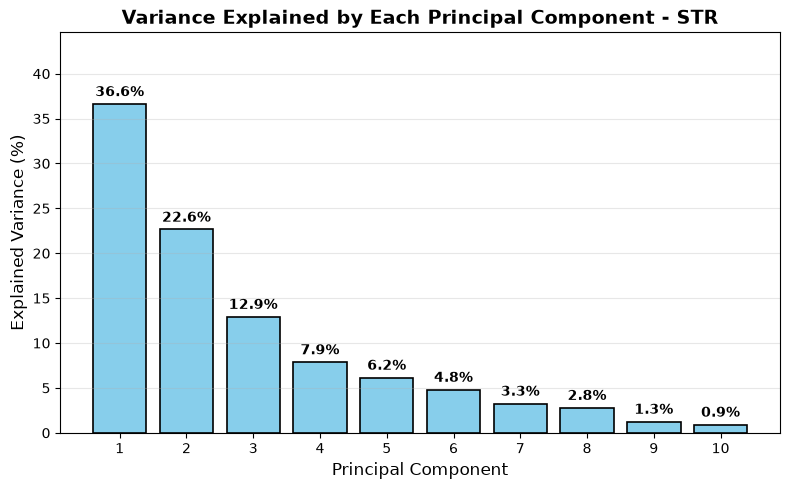

In [52]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Percentage of explained variance
explained = pca1.explained_variance_ratio_ * 100

# Create figure
plt.figure(figsize=(8, 5))

# Bar plot
bars = plt.bar(
    range(1, len(explained) + 1),
    explained,
    color="skyblue",
    edgecolor="black",
    linewidth=1.2
)

# Add percentage labels with black outline
for bar, value in zip(bars, explained):

    txt = plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


# Labels and title
plt.xlabel("Principal Component", fontsize=12)
plt.ylabel("Explained Variance (%)", fontsize=12)
plt.title(
    "Variance Explained by Each Principal Component - STR",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(range(1, len(explained) + 1))
plt.ylim(0, max(explained) + 8)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

In [53]:
import numpy as np

for i in range(1, len(pca1.explained_variance_ratio_) + 1):
    x = np.sum(pca1.explained_variance_ratio_[:i])

    if x >= 0.8:
        print(f"To obtain at least 80% of the explained variance, {i} principal components are required which sum up to {x*100:.2f}%.")
        break

To obtain at least 80% of the explained variance, 4 principal components are required which sum up to 80.09%.


In [54]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_juv_str_pca = pca.fit_transform(X_juv_str_scaled)

In [55]:
print(f"The value of the PCA: \n PCA1 : {pca.explained_variance_ratio_[0]},\n PCA2 : {pca.explained_variance_ratio_[1]} \n PCA3 : {pca.explained_variance_ratio_[2]} ")
print(f"And the sum is:", pca.explained_variance_ratio_.sum())

The value of the PCA: 
 PCA1 : 0.3662983757390585,
 PCA2 : 0.22649515403981352 
 PCA3 : 0.12935161149644325 
And the sum is: 0.7221451412753153


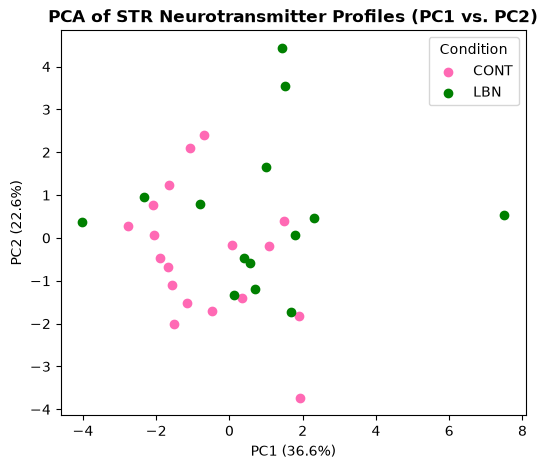

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    X_juv_str_pca[Y_juv_str == 0, 0],
    X_juv_str_pca[Y_juv_str == 0, 1],
    label="CONT",
    color="hotpink"
)

plt.scatter(
    X_juv_str_pca[Y_juv_str == 1, 0],
    X_juv_str_pca[Y_juv_str == 1, 1],
    label="LBN",
    color="green"
)

plt.title("PCA of STR Neurotransmitter Profiles (PC1 vs. PC2)", fontweight='semibold')

plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"
)

plt.legend(title="Condition")
plt.show()

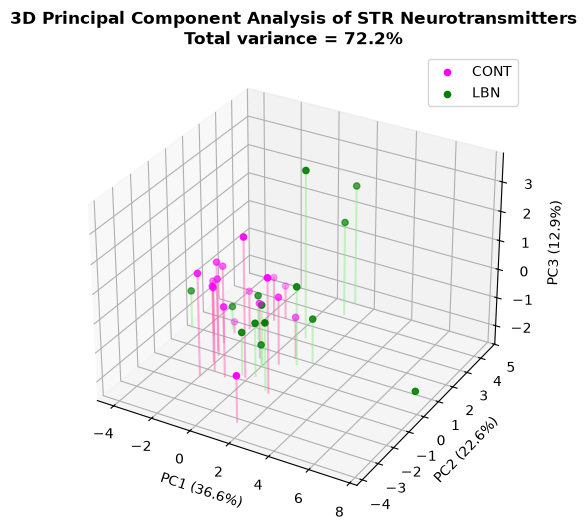

In [57]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

zmin = X_juv_str_pca[:,2].min() # here we define the minimum value of the z-axis to be used for the needle lines. This is set to the minimum value of the third principal component (PC3) in the PCA-transformed data.

# if you don't want the needle lines to the bottom of the plot, you can comment out these two lines
for x, y, z in X_juv_str_pca[Y_juv_str==0, :3]:
     ax.plot([x, x], [y, y], [zmin, z], color='hotpink', alpha=0.5)

ax.scatter(
    X_juv_str_pca[Y_juv_str==0,0],
    X_juv_str_pca[Y_juv_str==0,1],
    X_juv_str_pca[Y_juv_str==0,2],
    label="CONT",
    color='magenta'
)

# if you don't want the needle lines to the bottom of the plot, you can comment out these two lines
for x, y, z in X_juv_str_pca[Y_juv_str==1, :3]:
    ax.plot([x, x], [y, y], [zmin, z], color='lightgreen', alpha=0.5)

ax.scatter(
    X_juv_str_pca[Y_juv_str==1,0],
    X_juv_str_pca[Y_juv_str==1,1],
    X_juv_str_pca[Y_juv_str==1,2],
    label="LBN",
    color='green'
)

ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
ax.set_zlabel(f"PC3 ({100*pca.explained_variance_ratio_[2]:.1f}%)")

ax.set_title(
    f"3D Principal Component Analysis of STR Neurotransmitters\n"
    f"Total variance = {100*sum(pca.explained_variance_ratio_[:3]):.1f}%",
    fontweight='semibold'
)

ax.legend()
plt.show()

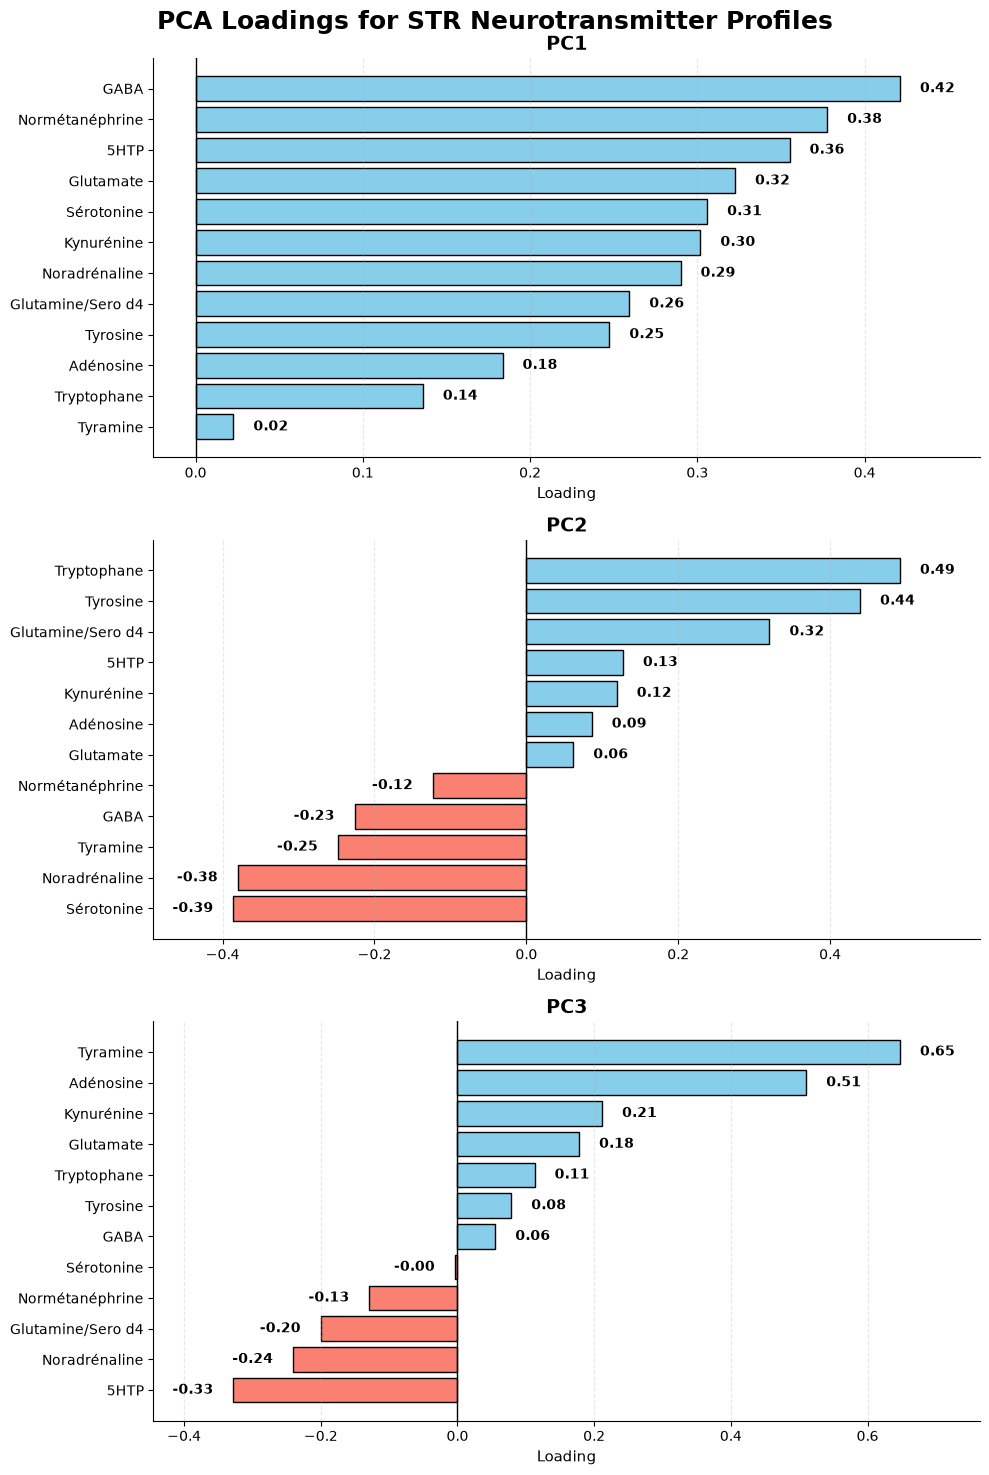

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# PCA loadings
loadings_str = pd.DataFrame(
    pca.components_.T,
    index=X_juv_str.columns,
    columns=["PC1", "PC2", "PC3"]
)

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

fig.suptitle(
    "PCA Loadings for STR Neurotransmitter Profiles",fontsize=18, fontweight="semibold"
)

for i, pc in enumerate(loadings_str.columns):
    ax = axes[i]
    values = loadings_str[pc].sort_values()
    colors = [ "skyblue" if v >= 0 else "salmon" for v in values]

    bars = ax.barh(
        values.index,
        values.values,
        color=colors,
        edgecolor="black"
    )

    ax.axvline(
        0,
        color="black",
        linewidth=1
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_title(
        pc,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Loading",
        fontsize=11
    )

    xmin = values.min()
    xmax = values.max()
    offset = (xmax - xmin) * 0.03

    ax.set_xlim(xmin - 4*offset, xmax + 4*offset)

    for bar, value in zip(bars, values):

        if value >= 0:
            ax.text(
                value + offset,
                bar.get_y() + bar.get_height()/2,
                f"{value:.2f}",
                va="center",
                ha="left",
                fontsize=10,
                fontweight="bold"
            )
        else:
            ax.text(
                value - offset,
                bar.get_y() + bar.get_height()/2,
                f"{value:.2f}",
                va="center",
                ha="right",
                fontsize=10,
                fontweight="bold"
            )

plt.tight_layout()
plt.show()

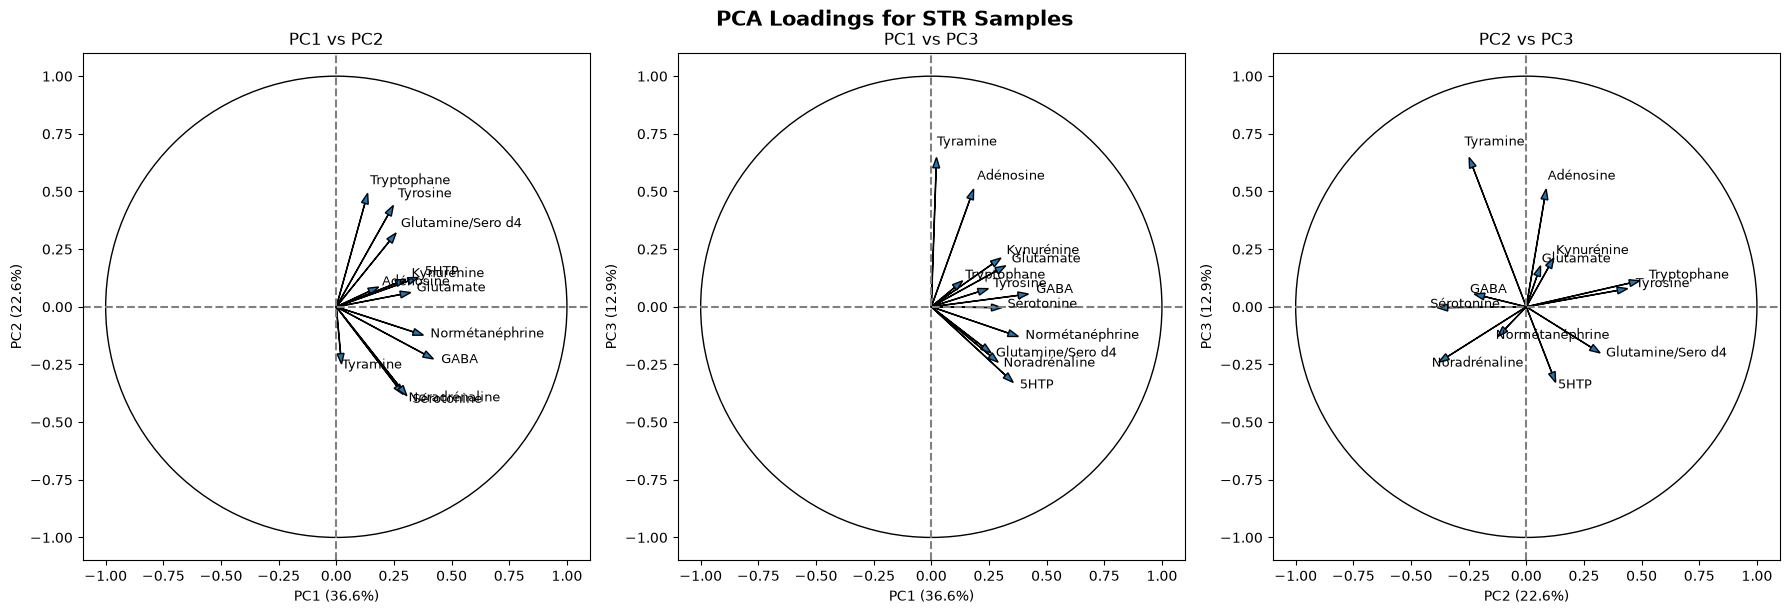

In [59]:
import matplotlib.pyplot as plt
import pandas as pd

# Loadings
loadings_str = pd.DataFrame(
    pca.components_.T,
    index=X_juv_str.columns,
    columns=["PC1", "PC2", "PC3"]
)

pairs = [
    ("PC1", "PC2"),
    ("PC1", "PC3"),
    ("PC2", "PC3")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "PCA Loadings for STR Samples",
    fontsize=15,
    fontweight="bold"
) 

for ax, (pcx, pcy) in zip(axes, pairs):

    # cercle
    circle = plt.Circle(
        (0, 0),
        1,
        fill=False,
        color="black"
    )
    ax.add_artist(circle)

    # flèches
    for nt in loadings_str.index:

        x = loadings_str.loc[nt, pcx]
        y = loadings_str.loc[nt, pcy]

        ax.arrow(
            0, 0,
            x, y,
            head_width=0.03,
            length_includes_head=True
        )

        ax.text(
            x*1.08,
            y*1.08,
            nt,
            fontsize=9
        )

    ax.axhline(0, color="grey", linestyle="--")
    ax.axvline(0, color="grey", linestyle="--")

    # Pourcentage expliqué
    pcx_num = int(pcx[-1]) - 1
    pcy_num = int(pcy[-1]) - 1

    ax.set_xlabel(
        f"{pcx} ({pca.explained_variance_ratio_[pcx_num]*100:.1f}%)"
    )

    ax.set_ylabel(
        f"{pcy} ({pca.explained_variance_ratio_[pcy_num]*100:.1f}%)"
    )

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")

    ax.set_title(f"{pcx} vs {pcy}")

plt.tight_layout()
plt.show()

### Hierarchical clustering

---

#### For the PFC

 <span style="font-weight: bold;"> Hierarchical clustering was performed to explore the similarity between PFC samples based on their standardized neurotransmitter profiles

  <span style="font-weight: bold;"> Clustering was performed using Ward's linkage and Euclidean distance. Euclidean distance measures the overall dissimilarity between samples. Ward's linkage was chosen because it minimizes the variance within clusters, resulting in compact and well-separated groups.

  <span style="font-weight: bold;"> The resulting heatmap visualizes the clustering of samples and neurotransmitters, with a legend indicating the experimental groups (CONT and LBN).

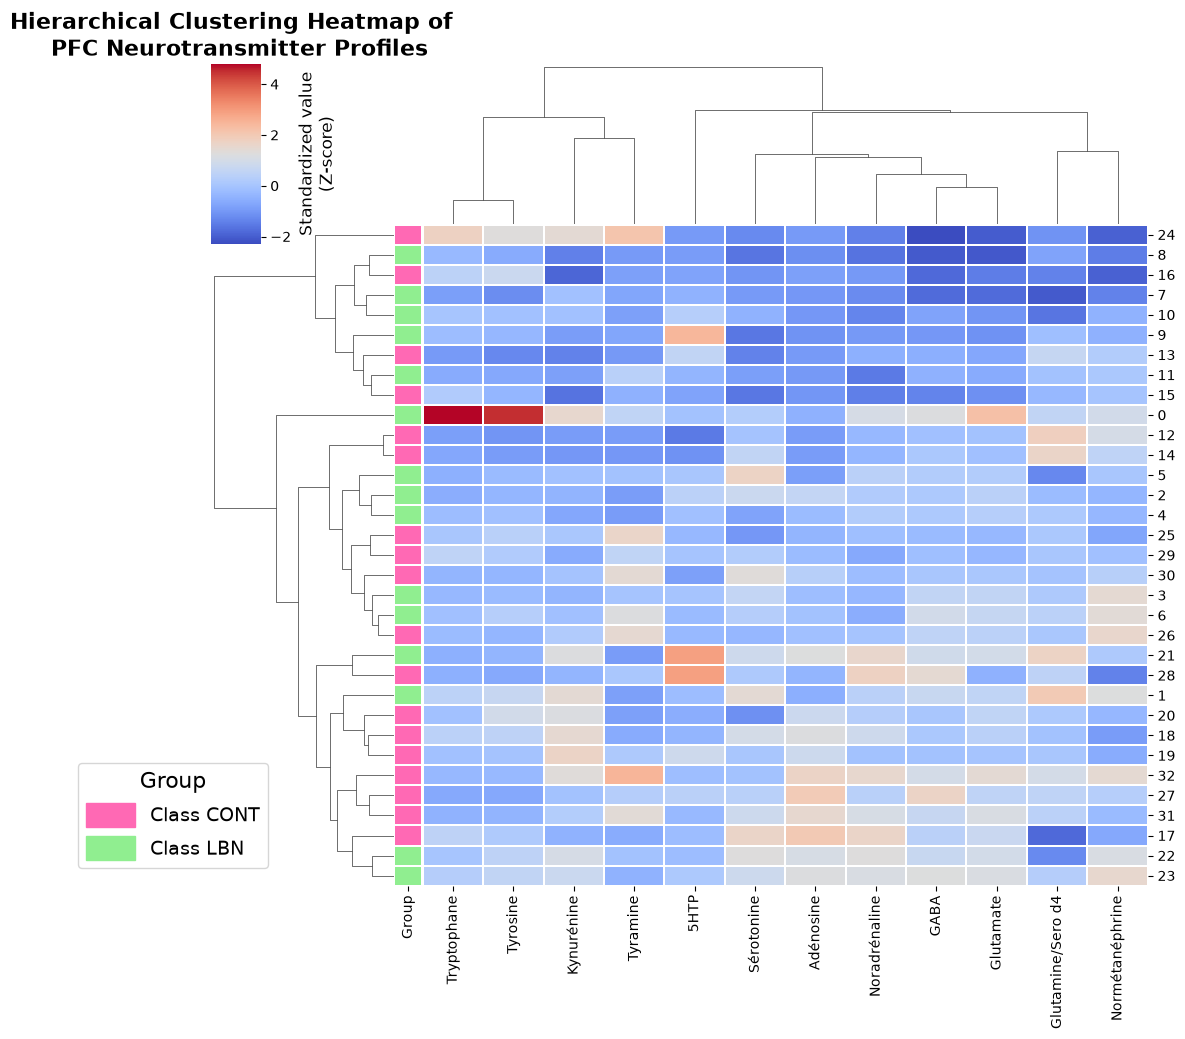

In [60]:
# Impute missing values using the median and standardize the data
# before hierarchical clustering
import matplotlib.patches as mpatches

imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X_juv_pfc_log)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# Assign colors to each sample according to its experimental group
row_colors = Y_juv_pfc.reset_index(drop=True).map({
    0: "hotpink",
    1: "lightgreen"
})

# Generate a hierarchical clustering heatmap using Ward's linkage
# and Euclidean distance on the standardized neurotransmitter data
g = sns.clustermap(
    pd.DataFrame(
        X_scaled,
        columns=X_juv_pfc_log.columns
    ),
    method="ward",
    metric="euclidean",
    cmap="coolwarm",
    row_colors=row_colors,
    linewidths=0.2,
    figsize=(10,10)
)

# Create and display a legend for the experimental groups
legend_handles = [
    mpatches.Patch(color="hotpink", label="Class CONT"),
    mpatches.Patch(color="lightgreen", label="Class LBN")
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Group",
    loc="upper right",
    bbox_to_anchor=(-0.2, 0.2),
    fontsize=14,
    title_fontsize=16,
    handlelength=2.5,
    handleheight=1.5
)

# Customize the color bar and figure title
g.cax.set_ylabel("Standardized value\n(Z-score)", fontsize=12)
plt.title("Hierarchical Clustering Heatmap of \n PFC Neurotransmitter Profiles", fontsize=16, fontweight="bold")

plt.show()

 <span style="font-weight: bold;"> Each sample was assigned to one of two clusters based on the hierarchical clustering results.
 A table was then created to compare the clusters with the experimental groups. This helps determine whether samples from the same group tend to cluster together or are mixed between the two clusters.

In [61]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(
    X_scaled,
    method="ward",
    metric="euclidean"
)

clusters = fcluster(
    Z,
    t=2,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "Group": Y_juv_pfc.reset_index(drop=True),
    "Cluster": clusters
})

ct = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Group"],
    margins = True
)

ct.columns = ["Class CONT", "Class LBN", "Total"]
ct.index.name = "Cluster"
print(ct)

         Class CONT  Class LBN  Total
Cluster                              
1                 4          5      9
2                14         10     24
All              18         15     33


<span style="font-weight: bold;"> Now we will calculate the Silhouette Score to evaluate the quality of the clustering.
The score measures how similar each data point is to its own cluster
compared to the nearest neighboring cluster.

<span style="font-weight: bold;"> Interpretation:

<span style="font-weight: bold;"> -  0.80 – 1.00	Excellent clustering; clusters are highly distinct.

<span style="font-weight: bold;"> - 0.60 – 0.80	Good clustering with clear separation.

<span style="font-weight: bold;"> - 0.40 – 0.60	Reasonable clustering; some overlap may exist.

<span style="font-weight: bold;"> - 0.20 – 0.40	Weak clustering; the groups are not well separated.

<span style="font-weight: bold;"> - < 0.20	Very poor clustering

<span style="font-weight: bold;"> - < 0	Incorrect clustering; many points are likely assigned to the wrong cluster.

 <span style="font-weight: bold;">  In general, a higher Silhouette Score indicates better-defined clusters

In [62]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.2754246282243953


<span style="font-weight: bold;"> So we have a weak clustering; the groups are not well separated.

---

#### For the HIP

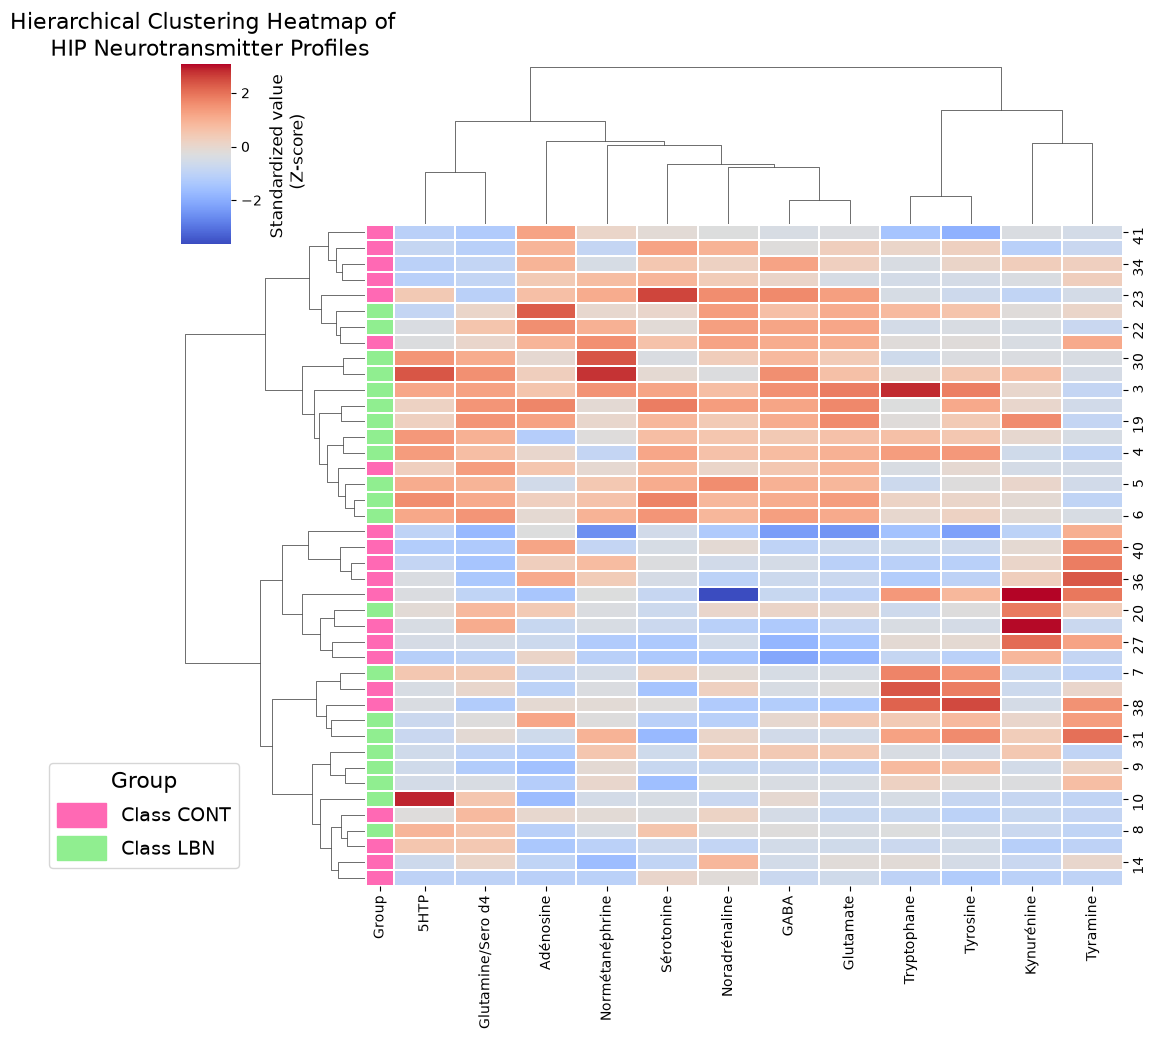

In [63]:
import matplotlib.patches as mpatches

imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X_juv_hip_log)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

row_colors = Y_juv_hip.reset_index(drop=True).map({
    0: "hotpink",
    1: "lightgreen"
})

g = sns.clustermap(
    pd.DataFrame(
        X_scaled,
        columns=X_juv_hip_log.columns
    ),
    method="ward",
    metric="euclidean",
    cmap="coolwarm",
    row_colors=row_colors,
    linewidths=0.2,
    figsize=(10,10)
)

legend_handles = [
    mpatches.Patch(color="hotpink", label="Class CONT"),
    mpatches.Patch(color="lightgreen", label="Class LBN")
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Group",
    loc="upper right",
    bbox_to_anchor=(-0.2, 0.2),
    fontsize=14,        
    title_fontsize=16,  
    handlelength=2.5,  
    handleheight=1.5    
)
g.cax.set_ylabel("Standardized value \n (Z-score)", fontsize=12)
plt.title("Hierarchical Clustering Heatmap of \n HIP Neurotransmitter Profiles", fontsize=16)
plt.show()

In [64]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(
    X_scaled,
    method="ward",
    metric="euclidean"
)

clusters = fcluster(
    Z,
    t=2,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "Group": Y_juv_hip.reset_index(drop=True),
    "Cluster": clusters
})

ct = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Group"],
    margins = True
)

ct.columns = ["Class CONT", "Class LBN", "Total"]
ct.index.name = "Cluster"
print(ct)

         Class CONT  Class LBN  Total
Cluster                              
1                 7         12     19
2                14          9     23
All              21         21     42


In [65]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.21348586142394596


<span style="font-weight: bold;"> So we have a weak clustering; the groups are not well separated.

---

#### For the STR

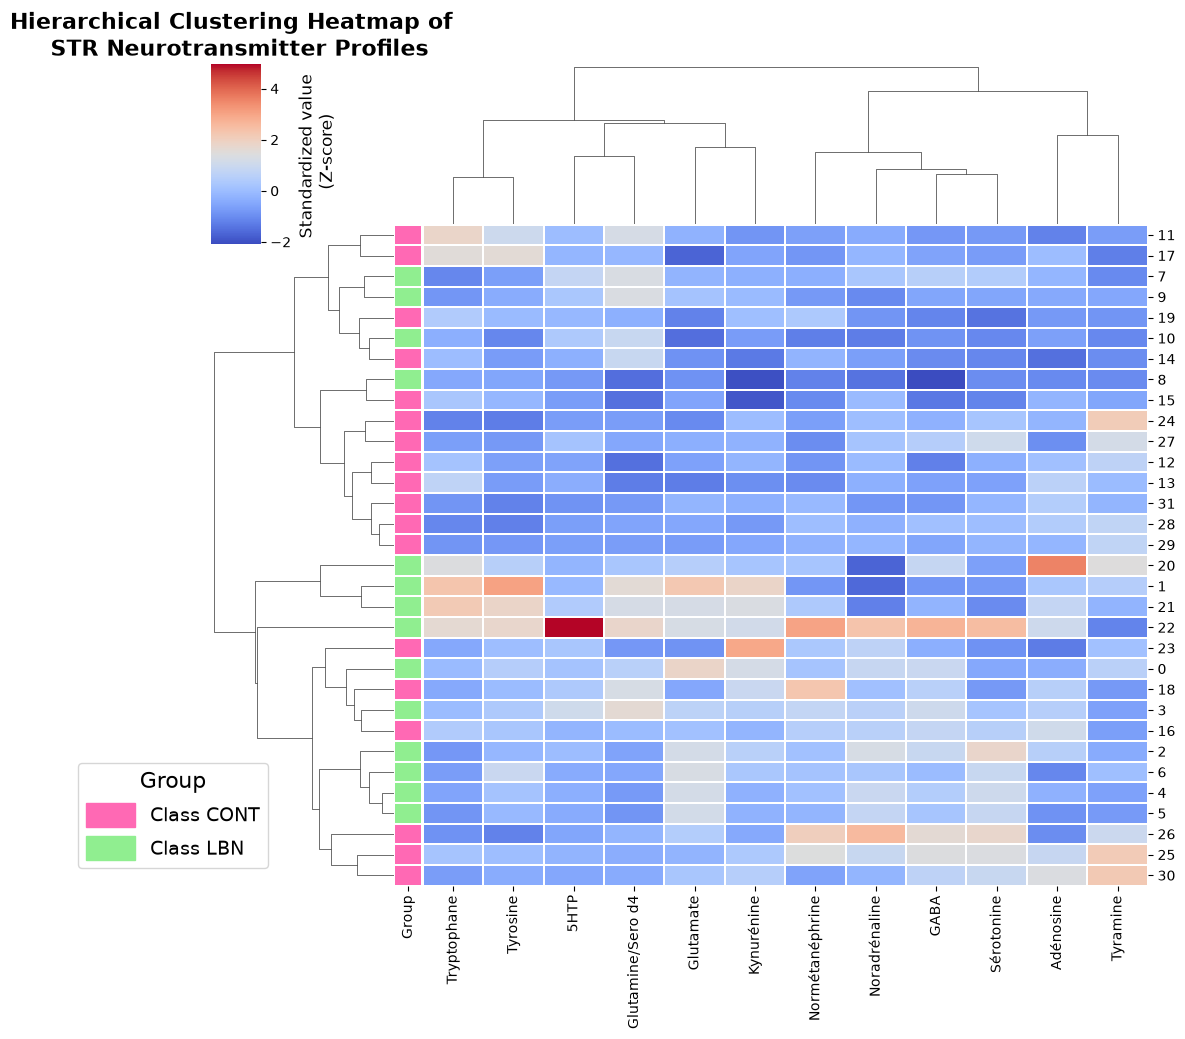

In [66]:
import matplotlib.patches as mpatches

imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X_juv_str_log)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

row_colors = Y_juv_str.reset_index(drop=True).map({
    0: "hotpink",
    1: "lightgreen"
})

g = sns.clustermap(
    pd.DataFrame(
        X_scaled,
        columns=X_juv_str_log.columns
    ),
    method="ward",
    metric="euclidean",
    cmap="coolwarm",
    row_colors=row_colors,
    linewidths=0.2,
    figsize=(10,10)
)

legend_handles = [
    mpatches.Patch(color="hotpink", label="Class CONT"),
    mpatches.Patch(color="lightgreen", label="Class LBN")
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Group",
    loc="upper right",
    bbox_to_anchor=(-0.2, 0.2),
    fontsize=14,        
    title_fontsize=16,  
    handlelength=2.5,  
    handleheight=1.5    
)
g.cax.set_ylabel("Standardized value \n (Z-score)", fontsize=12)
plt.title("Hierarchical Clustering Heatmap of \n STR Neurotransmitter Profiles", fontsize=16, fontweight="bold")
plt.show()

In [67]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(
    X_scaled,
    method="ward",
    metric="euclidean"
)

clusters = fcluster(
    Z,
    t=2,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "Group": Y_juv_str.reset_index(drop=True),
    "Cluster": clusters
})

ct = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Group"],
    margins = True
)

ct.columns = ["Class CONT", "Class LBN", "Total"]
ct.index.name = "Cluster"
print(ct)

         Class CONT  Class LBN  Total
Cluster                              
1                12          4     16
2                 6         10     16
All              18         14     32


In [68]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.19378549380974514


<span style="font-weight: bold;"> So we have a Very poor clustering result for the STR samples, even after removing the outlier. The silhouette score is low.

### Logistic Regression

--- 

#### For the PFC

<span style="font-weight: bold;"> Now we will perform a logistic regression analysis to predict the experimental group (CONT vs LBN) based on the standardized neurotransmitter profiles in the PFC dataset.

<span style="font-weight: bold;">Model parameters:  
 <span style="font-weight: bold;">- penalty="l2": Instead of removing variables, L2 regularization penalizes large coefficients by adding a penalty proportional to their squared values during model fitting. This reduces overfitting.  
 <span style="font-weight: bold;">- C=1: default regularization strength. Controls how much the model avoids overfitting; smaller C means a simpler model, while larger C means the model fits the training data more closely.  
 <span style="font-weight: bold;">- class_weight="balanced": compensates for class imbalance by assigning higher weights to the minority class.

 <span style="font-weight: bold;">Model performance is evaluated using repeated stratified 5-fold cross-validation.  
  <span style="font-weight: bold;">- n_splits=5: the dataset is divided into five folds.  
  <span style="font-weight: bold;"> - n_repeats=20: the entire procedure is repeated 20 times with different splits to obtain a more robust estimate of performance.  
 <span style="font-weight: bold;"> - Stratification preserves the class proportions in each fold.



In [69]:
log_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

log_scores_pfc = cross_val_score(
    log_pipe,
    X_juv_pfc_log,
    Y_juv_pfc,
    cv=cv,
    scoring="roc_auc"
)

<span style="font-weight: bold;">Model performance was evaluated using four complementary metrics: accuracy, sensitivity, specificity, and the area under the receiver operating characteristic curve (ROC-AUC). 

<span style="font-weight: bold;"> - Accuracy represents the proportion of correctly classified animals.  
<span style="font-weight: bold;"> - Sensitivity measures the proportion of LBN animals correctly identified by the model.  
<span style="font-weight: bold;"> - Specificity measures the proportion of CONT animals correctly classified.   
<span style="font-weight: bold;"> -  The Receiver Operating Characteristic (ROC) curve evaluates the performance of the classifier across a range of decision thresholds by plotting the true positive rate (sensitivity) against the false positive rate (1 − specificity).   

<span style="font-weight: bold;">The Area Under the ROC Curve (AUC) summarizes the model’s ability to correctly distinguish between positive and negative cases.


In [70]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score

# Sensitivity = Recall of positive class (LBN = 1)
sensitivity = make_scorer(
    recall_score,
    pos_label=1
)

# Specificity = Recall of negative class (CONT = 0)
specificity = make_scorer(
    recall_score,
    pos_label=0
)

scores = cross_validate(
    log_pipe,
    X_juv_pfc_log,
    Y_juv_pfc,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "auc": "roc_auc",
        "sensitivity": sensitivity,
        "specificity": specificity
    },
    n_jobs=-1
)

print("===== Logistic Regression =====")

print(f"Accuracy    = {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")

print(f"Sensitivity = {scores['test_sensitivity'].mean():.3f} ± {scores['test_sensitivity'].std():.3f}")

print(f"Specificity = {scores['test_specificity'].mean():.3f} ± {scores['test_specificity'].std():.3f}")

print(f"AUC         = {scores['test_auc'].mean():.3f} ± {scores['test_auc'].std():.3f}")

===== Logistic Regression =====
Accuracy    = 0.632 ± 0.152
Sensitivity = 0.667 ± 0.291
Specificity = 0.594 ± 0.246
AUC         = 0.732 ± 0.179


 <span style="font-weight: bold;"> The evaluation metric is the Area Under the ROC Curve (ROC-AUC), which measures
 the model's ability to distinguish between the two classes. A ROC-AUC of:  
  <span style="font-weight: bold;"> - 1.0 indicates perfect discrimination.  
 <span style="font-weight: bold;"> - 0.9–1.0 is considered excellent.  
 <span style="font-weight: bold;"> - 0.8–0.9 is considered good.  
 <span style="font-weight: bold;"> - 0.7–0.8 is considered acceptable.  
 <span style="font-weight: bold;"> - 0.5 indicates performance no better than random guessing.  

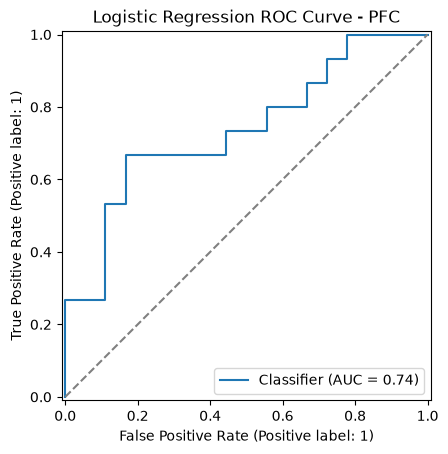

In [71]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    log_pipe,
    X_juv_pfc_log,
    Y_juv_pfc,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_juv_pfc,
    y_prob
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Logistic Regression ROC Curve - PFC")
plt.show()

In [72]:
log_pipe.fit(X_juv_pfc_log, Y_juv_pfc)

coef = pd.DataFrame({
    "NT": X_juv_pfc_log.columns,
    "Coefficient":
        log_pipe.named_steps["logreg"].coef_[0]
})
coef = coef.sort_values(by="Coefficient", ascending=False)

 <span style="font-weight: bold;"> Logistic Regression Coefficients  
The bar plot shows the logistic regression coefficients for each neurotransmitter after model fitting. Positive coefficients (blue) indicate that higher values of the neurotransmitter increase the predicted probability of the LBN class, while negative coefficients (red) indicate an association with the CONT group.

findfont: Failed to find font weight semibold, now using 700.


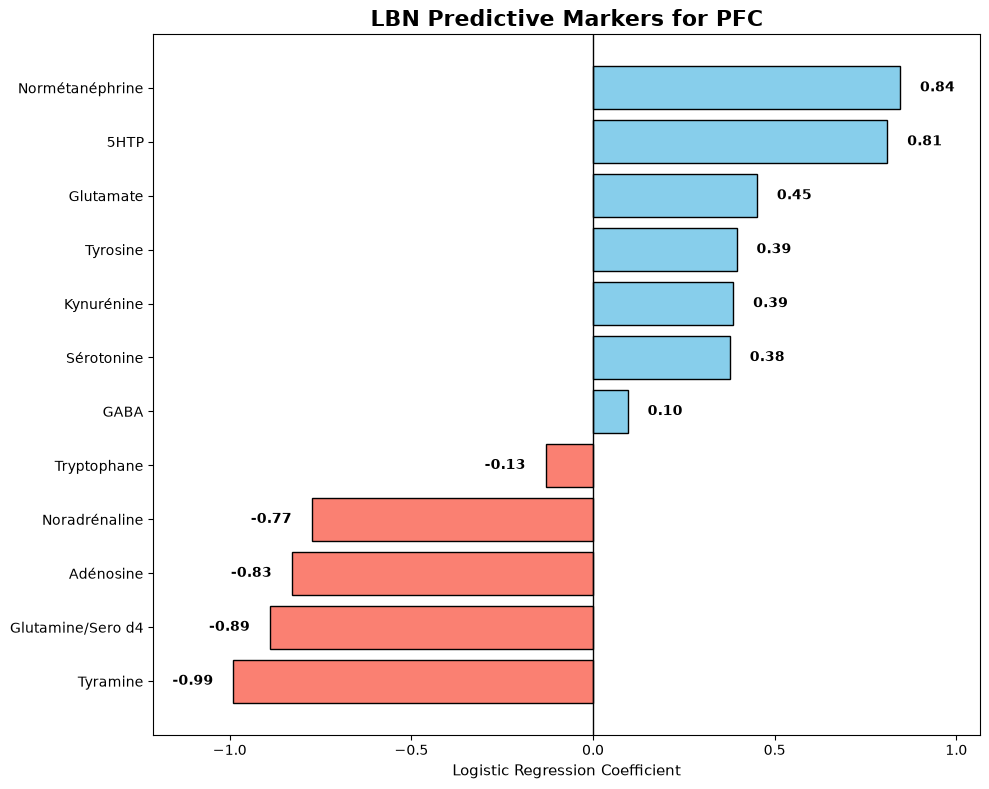

In [73]:
import matplotlib.pyplot as plt

# Sort coefficients
coef = coef.sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(10, 8))

# Color bars by sign
colors = [
    "skyblue" if v >= 0 else "salmon"
    for v in coef["Coefficient"]
]

bars = ax.barh(
    coef["NT"],
    coef["Coefficient"],
    color=colors,
    edgecolor="black"
)

# Reference line at 0
ax.axvline(
    0,
    color="black",
    linewidth=1
)


# Labels and title
ax.set_title(
    "LBN Predictive Markers for PFC",
    fontsize=16,
    fontweight="semibold"
)

ax.set_xlabel(
    "Logistic Regression Coefficient",
    fontsize=11
)

# Add coefficient values
xmin = coef["Coefficient"].min()
xmax = coef["Coefficient"].max()
offset = (xmax - xmin) * 0.03

ax.set_xlim(xmin - 4 * offset, xmax + 4 * offset)

for bar, value in zip(bars, coef["Coefficient"]):

    if value >= 0:
        ax.text(
            value + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold"
        )
    else:
        ax.text(
            value - offset,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va="center",
            ha="right",
            fontsize=10,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

In [74]:
print(f"Values of coefficients for PFC:\n{coef.sort_values('Coefficient', ascending=False)}")

Values of coefficients for PFC:
                   NT  Coefficient
7     Normétanéphrine     0.844977
0                5HTP     0.809766
3           Glutamate     0.451109
11           Tyrosine     0.394967
5          Kynurénine     0.385617
8          Sérotonine     0.376486
2                GABA     0.095373
9         Tryptophane    -0.130409
6       Noradrénaline    -0.774027
1           Adénosine    -0.828866
4   Glutamine/Sero d4    -0.889124
10           Tyramine    -0.989861


 <span style="font-weight: bold;">  To evaluate the stability of the logistic regression coefficients, bootstrap resampling is performed using 1,000 iterations. In each iteration, a new dataset is generated by sampling the original observations with replacement, the logistic regression pipeline is refitted, and the resulting coefficients are stored. The distribution of these bootstrap coefficients can then be used to assess the robustness of each feature's estimated effect.

In [75]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

coef_boot = pd.DataFrame(
    columns=X_juv_pfc_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_juv_pfc_log,
        Y_juv_pfc,
        replace=True,
        random_state=i
    )

    # Fit pipeline
    log_pipe.fit(X_boot, Y_boot)

    # Save coefficients
    coef_boot.loc[i] = log_pipe.named_steps["logreg"].coef_[0]

In [76]:
summary = pd.DataFrame({
    "Mean": coef_boot.mean(),
    "Lower95": coef_boot.quantile(0.025),
    "Upper95": coef_boot.quantile(0.975)
})

summary

,Mean,Lower95,Upper95
5HTP,0.764880,0.017711,1.406639
Adénosine,-0.802491,-1.400076,-0.192587
GABA,0.148104,-0.407934,0.744578
Glutamate,0.374877,-0.256122,1.046622
Glutamine/Sero d4,-0.856864,-1.504245,-0.117857
Kynurénine,0.287555,-0.476359,0.992925
Noradrénaline,-0.638912,-1.276529,0.047995
Normétanéphrine,0.778887,0.035712,1.383154
Sérotonine,0.361178,-0.347640,1.066829
Tryptophane,-0.185189,-0.955994,0.425413


 <span style="font-weight: bold;"> Bootstrap Results    
 The bootstrap analysis estimated the mean logistic regression coefficient and its 95% confidence interval for each neurotransmitter across 1,000 resampled datasets.  
Features whose confidence intervals do not include zero are considered the most stable predictors.  
In this analysis, **5HTP** and **Normétanéphrine** showed consistently positive coefficients, whereas **Adénosine**, **Glutamine/Sero d4**, and **Tyramine** showed consistently negative coefficients. The 95% confidence intervals for these five features did not cross zero, suggesting that they are the most robust predictors in the model.

---

#### For the HIP

In [77]:
log_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

log_scores_hip = cross_val_score(
    log_pipe,
    X_juv_hip_log,
    Y_juv_hip,
    cv=cv,
    scoring="roc_auc"
)

In [78]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score

# Sensitivity = Recall of positive class (LBN = 1)
sensitivity = make_scorer(
    recall_score,
    pos_label=1
)

# Specificity = Recall of negative class (CONT = 0)
specificity = make_scorer(
    recall_score,
    pos_label=0
)

scores = cross_validate(
    log_pipe,
    X_juv_hip_log,
    Y_juv_hip,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "auc": "roc_auc",
        "sensitivity": sensitivity,
        "specificity": specificity
    },
    n_jobs=-1
)

print("===== Logistic Regression =====")

print(f"Accuracy    = {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")

print(f"Sensitivity = {scores['test_sensitivity'].mean():.3f} ± {scores['test_sensitivity'].std():.3f}")

print(f"Specificity = {scores['test_specificity'].mean():.3f} ± {scores['test_specificity'].std():.3f}")

print(f"AUC         = {scores['test_auc'].mean():.3f} ± {scores['test_auc'].std():.3f}")

===== Logistic Regression =====
Accuracy    = 0.719 ± 0.127
Sensitivity = 0.747 ± 0.215
Specificity = 0.691 ± 0.226
AUC         = 0.818 ± 0.162


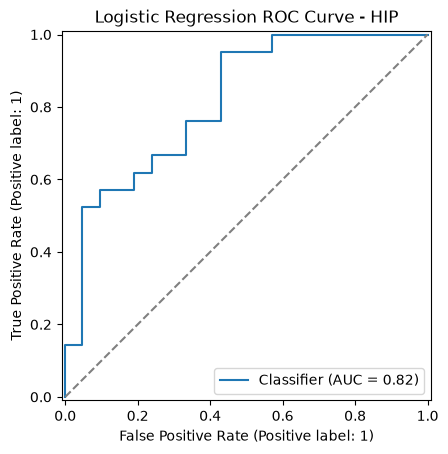

In [79]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    log_pipe,
    X_juv_hip_log,
    Y_juv_hip,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_juv_hip,
    y_prob
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Logistic Regression ROC Curve - HIP")
plt.show()

In [80]:
log_pipe.fit(X_juv_hip_log, Y_juv_hip)

coef = pd.DataFrame({
    "NT": X_juv_hip_log.columns,
    "Coefficient":
        log_pipe.named_steps["logreg"].coef_[0]
})
coef = coef.sort_values(by="Coefficient", ascending=False)

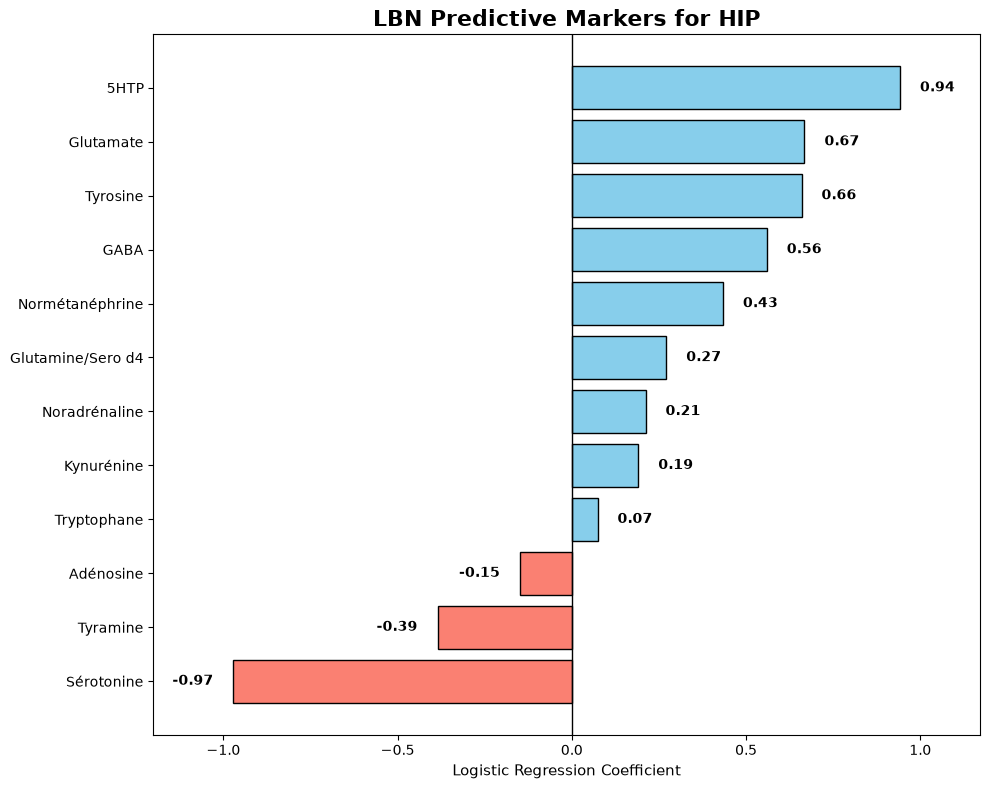

In [81]:
import matplotlib.pyplot as plt

# Sort coefficients
coef = coef.sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(10, 8))

# Color bars by sign
colors = [
    "skyblue" if v >= 0 else "salmon"
    for v in coef["Coefficient"]
]

bars = ax.barh(
    coef["NT"],
    coef["Coefficient"],
    color=colors,
    edgecolor="black"
)

# Reference line at 0
ax.axvline(
    0,
    color="black",
    linewidth=1
)



# Labels and title
ax.set_title(
    "LBN Predictive Markers for HIP",
    fontsize=16,
    fontweight="semibold"
)

ax.set_xlabel(
    "Logistic Regression Coefficient",
    fontsize=11
)

# Add coefficient values
xmin = coef["Coefficient"].min()
xmax = coef["Coefficient"].max()
offset = (xmax - xmin) * 0.03

ax.set_xlim(xmin - 4 * offset, xmax + 4 * offset)

for bar, value in zip(bars, coef["Coefficient"]):

    if value >= 0:
        ax.text(
            value + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold"
        )
    else:
        ax.text(
            value - offset,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va="center",
            ha="right",
            fontsize=10,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

In [82]:
print(f"Values of coefficients for HIP:\n{coef.sort_values('Coefficient', ascending=False)}")

Values of coefficients for HIP:
                   NT  Coefficient
0                5HTP     0.941785
3           Glutamate     0.667705
11           Tyrosine     0.659151
2                GABA     0.559615
7     Normétanéphrine     0.433759
4   Glutamine/Sero d4     0.271028
6       Noradrénaline     0.211574
5          Kynurénine     0.190795
9         Tryptophane     0.073743
1           Adénosine    -0.148667
10           Tyramine    -0.385325
8          Sérotonine    -0.971182


In [83]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

coef_boot = pd.DataFrame(
    columns=X_juv_hip_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_juv_hip_log,
        Y_juv_hip,
        replace=True,
        random_state=i
    )

    # Fit pipeline
    log_pipe.fit(X_boot, Y_boot)

    # Save coefficients
    coef_boot.loc[i] = log_pipe.named_steps["logreg"].coef_[0]

In [84]:
summary = pd.DataFrame({
    "Mean": coef_boot.mean(),
    "Lower95": coef_boot.quantile(0.025),
    "Upper95": coef_boot.quantile(0.975)
})

summary

,Mean,Lower95,Upper95
5HTP,0.896811,0.350039,1.417211
Adénosine,-0.262148,-0.989034,0.454122
GABA,0.595893,0.096693,1.072266
Glutamate,0.658521,0.035297,1.282307
Glutamine/Sero d4,0.392349,-0.401903,1.216817
Kynurénine,0.243253,-0.504748,1.033104
Noradrénaline,0.219103,-0.620785,1.041725
Normétanéphrine,0.474406,-0.237585,1.107748
Sérotonine,-0.837442,-1.549791,-0.004787
Tryptophane,0.226611,-0.561332,1.062497


 <span style="font-weight: bold;"> In this analysis, **5HTP**, **GABA**, **Glutamate**, and **Tyrosine** showed consistently positive coefficients, while **Sérotonine** showed a consistently negative coefficient.

---

#### For the STR

In [85]:
log_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=5000,
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

log_scores_str = cross_val_score(
    log_pipe,
    X_juv_str_log,
    Y_juv_str,
    cv=cv,
    scoring="roc_auc"
)

In [86]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score

# Sensitivity = Recall of positive class (LBN = 1)
sensitivity = make_scorer(
    recall_score,
    pos_label=1
)

# Specificity = Recall of negative class (CONT = 0)
specificity = make_scorer(
    recall_score,
    pos_label=0
)

scores = cross_validate(
    log_pipe,
    X_juv_str_log,
    Y_juv_str,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "auc": "roc_auc",
        "sensitivity": sensitivity,
        "specificity": specificity
    },
    n_jobs=-1
)

print("===== Logistic Regression =====")

print(f"Accuracy    = {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")

print(f"Sensitivity = {scores['test_sensitivity'].mean():.3f} ± {scores['test_sensitivity'].std():.3f}")

print(f"Specificity = {scores['test_specificity'].mean():.3f} ± {scores['test_specificity'].std():.3f}")

print(f"AUC         = {scores['test_auc'].mean():.3f} ± {scores['test_auc'].std():.3f}")

===== Logistic Regression =====
Accuracy    = 0.808 ± 0.135
Sensitivity = 0.780 ± 0.217
Specificity = 0.831 ± 0.198
AUC         = 0.877 ± 0.150


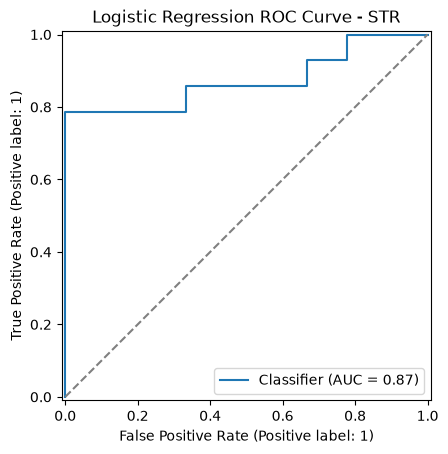

In [87]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    log_pipe,
    X_juv_str_log,
    Y_juv_str,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_juv_str,
    y_prob
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Logistic Regression ROC Curve - STR")
plt.show()

In [88]:
log_pipe.fit(X_juv_str_log, Y_juv_str)

coef = pd.DataFrame({
    "NT": X_juv_str_log.columns,
    "Coefficient":
        log_pipe.named_steps["logreg"].coef_[0]
})
coef = coef.sort_values(by="Coefficient", ascending=False)

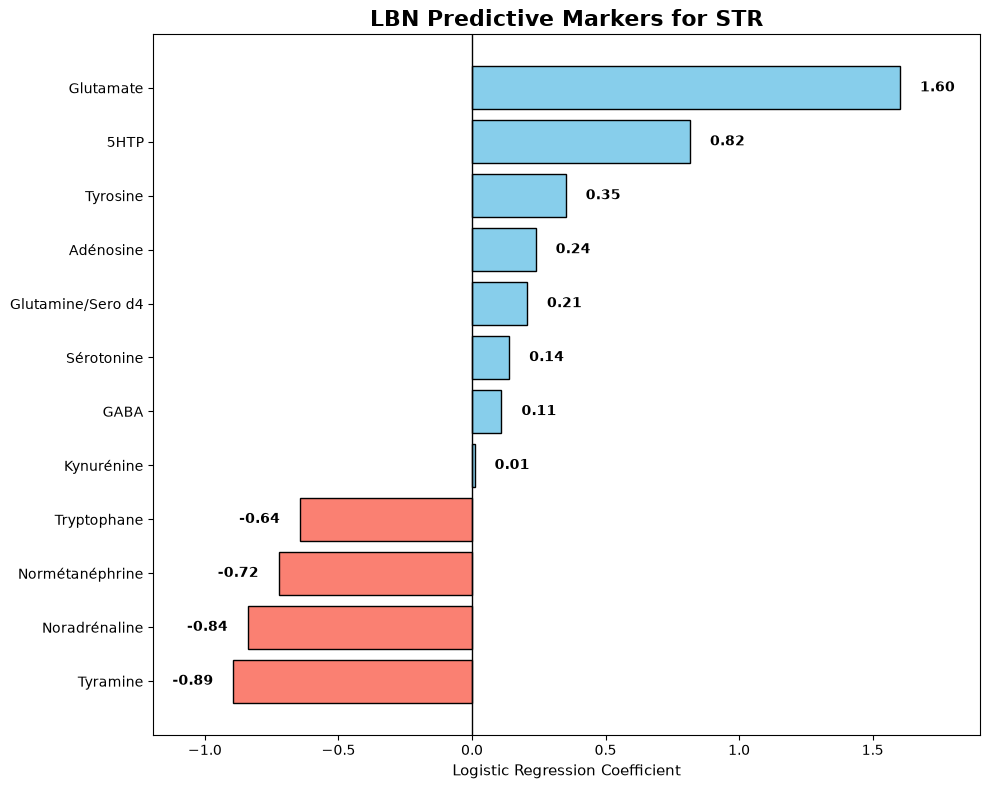

In [89]:
import matplotlib.pyplot as plt

# Sort coefficients
coef = coef.sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(10, 8))

# Color bars by sign
colors = [
    "skyblue" if v >= 0 else "salmon"
    for v in coef["Coefficient"]
]

bars = ax.barh(
    coef["NT"],
    coef["Coefficient"],
    color=colors,
    edgecolor="black"
)

# Reference line at 0
ax.axvline(
    0,
    color="black",
    linewidth=1
)



# Labels and title
ax.set_title(
    "LBN Predictive Markers for STR",
    fontsize=16,
    fontweight="semibold"
)

ax.set_xlabel(
    "Logistic Regression Coefficient",
    fontsize=11
)

# Add coefficient values
xmin = coef["Coefficient"].min()
xmax = coef["Coefficient"].max()
offset = (xmax - xmin) * 0.03

ax.set_xlim(xmin - 4 * offset, xmax + 4 * offset)

for bar, value in zip(bars, coef["Coefficient"]):

    if value >= 0:
        ax.text(
            value + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold"
        )
    else:
        ax.text(
            value - offset,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va="center",
            ha="right",
            fontsize=10,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

In [90]:
print(f"Values of coefficients for STR:\n{coef.sort_values('Coefficient', ascending=False)}")

Values of coefficients for STR:
                   NT  Coefficient
3           Glutamate     1.602371
0                5HTP     0.816195
11           Tyrosine     0.351004
1           Adénosine     0.238601
4   Glutamine/Sero d4     0.205918
8          Sérotonine     0.139286
2                GABA     0.110420
5          Kynurénine     0.009884
9         Tryptophane    -0.643508
7     Normétanéphrine    -0.723396
6       Noradrénaline    -0.838630
10           Tyramine    -0.893229


In [91]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

coef_boot = pd.DataFrame(
    columns=X_juv_str_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_juv_str_log,
        Y_juv_str,
        replace=True,
        random_state=i
    )

    # Fit pipeline
    log_pipe.fit(X_boot, Y_boot)

    # Save coefficients
    coef_boot.loc[i] = log_pipe.named_steps["logreg"].coef_[0]

In [92]:
summary = pd.DataFrame({
    "Mean": coef_boot.mean(),
    "Lower95": coef_boot.quantile(0.025),
    "Upper95": coef_boot.quantile(0.975)
})

summary

,Mean,Lower95,Upper95
5HTP,0.715323,0.290217,1.133968
Adénosine,0.135013,-0.618262,0.734010
GABA,0.060110,-0.397980,0.537597
Glutamate,1.511494,1.006567,1.949120
Glutamine/Sero d4,0.248681,-0.435602,0.960672
Kynurénine,0.056707,-0.500217,0.736081
Noradrénaline,-0.656526,-1.225418,-0.003667
Normétanéphrine,-0.596363,-1.128000,0.030191
Sérotonine,0.215146,-0.277038,0.656068
Tryptophane,-0.529787,-1.055238,0.075000


 <span style="font-weight: bold;"> In this analysis, **5HTP** and **Glutamate** showed consistently positive coefficients, while **Noradrénaline** and **Tyramine** showed consistently negative coefficients. The 95% confidence intervals for these neurotransmitters did not cross zero

### Random Forest

---

#### For the PFC

 <span style="font-weight: bold;"> A Random Forest classifier was implemented to evaluate whether neurotransmitter profiles could distinguish between the two experimental groups.  
 Missing values were handled using median imputation. Class weighting was applied to account for potential class imbalance. Model performance was assessed using repeated stratified 5-fold cross-validation (5 folds repeated 20 times), preserving class proportions in each split. The area under the receiver operating characteristic curve (ROC-AUC) was used as the evaluation metric, measuring the model's ability to rank samples from the positive class above the negative class. Mean AUC and standard deviation were calculated to evaluate both predictive performance and model stability.

In [93]:
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
    n_estimators=200, #Number of trees.
    max_depth=3, #Each tree can only make 3 splits.
    min_samples_leaf=2, #Minimum animals at the end of a branch.
    min_samples_split=4, #Minimum animals to consider a split.
    max_features="sqrt", #Number of features to consider at each split. Random Forest does NOT examine all variables.
    #If every tree always sees all NTs:become very similar. The forest loses diversity. Random feature selection creates more independent trees.
    class_weight="balanced", #Balance the classes.
    random_state=42 #Fixes randomness.
    ))
])

#Cross-validation strategy is a technique used to check how well a ML model performs on unseen data while preventing overfitting. 
# RepeatedStratifiedKFold is a specific method that combines stratified K-fold cross-validation with multiple repetitions to provide a more robust estimate of model performance, especially for imbalanced datasets.
# Stratified K-fold means that the folds are made by preserving the percentage of samples for each class. 
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

rf_scores = cross_val_score(
    rf_pipe,
    X_juv_pfc_log,
    Y_juv_pfc,
    cv=cv,
    scoring="roc_auc",
    #Receiver Operating Characteristic Area Under the Curve uses the true positive rate and false positive rate at various threshold settings to evaluate the performance of a binary classifier. 
    #The AUC represents the probability that a randomly chosen positive instance is ranked higher than a randomly chosen negative instance by the model.
    #AUC is the probability that: a randomly chosen LBN animal receives a higher predicted score than a randomly chosen CONT animal.
    n_jobs=-1

)

print("===== Random Forest =====")
print("Fold AUCs:", np.round(rf_scores, 3))
print(f"Mean AUC = {rf_scores.mean():.3f}")
print(f"SD = {rf_scores.std():.3f}")

===== Random Forest =====
Fold AUCs: [0.417 0.833 1.    0.778 0.667 0.417 0.667 0.5   0.444 0.778 0.583 0.75
 0.917 0.444 0.444 0.583 1.    0.167 0.778 1.    0.667 0.5   0.75  0.778
 0.889 0.583 0.417 0.833 0.889 0.778 0.5   0.917 0.75  1.    1.    0.917
 0.417 0.75  0.444 0.667 0.75  0.75  0.5   0.667 0.889 0.417 0.667 0.75
 0.333 1.    0.583 0.583 0.083 0.889 0.667 0.583 0.833 0.333 0.556 0.333
 1.    0.75  0.333 0.556 0.778 0.583 0.583 0.5   0.889 0.778 0.75  0.75
 0.5   0.889 0.444 0.75  0.667 0.75  0.667 0.667 0.417 0.333 0.583 0.556
 0.778 0.333 0.25  0.667 0.778 0.222 0.167 0.667 0.667 0.667 0.889 0.333
 0.25  0.333 0.444 0.889]
Mean AUC = 0.636
SD = 0.218


<span style="font-weight: bold;"> The Random Forest model achieved a mean ROC-AUC of **0.636 ± 0.218** across 100 repeated stratified cross-validation folds. This indicates that the model has a moderate ability to distinguish between the two classes, performing better than random guessing (AUC = 0.5).
The large standard deviation shows that the model performance varied a lot between different cross-validation splits. Some folds showed good performance (AUC close to 1.0), while others performed poorly (AUC below 0.5). This suggests its predictive ability should therefore be interpreted with caution.

<span style="font-weight: bold;">
After training the Random Forest model, feature importance scores were extracted to identify which neurotransmitters contributed most to classification. The importance values reflect the relative contribution of each feature within the decision trees of the model, with higher values indicating greater influence on the model's predictions.

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

# Fit Random Forest model
rf_pipe.fit(
    X_juv_pfc_log,
    Y_juv_pfc
)

# Extract trained Random Forest
rf = rf_pipe.named_steps["rf"]

# Create importance dataframe
rf_importance = pd.DataFrame({
    "NT": X_juv_pfc_log.columns,
    "Importance": rf.feature_importances_
})

# Sort by importance
rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print(rf_importance)

                   NT  Importance
0                5HTP    0.129461
1           Adénosine    0.109749
2     Normétanéphrine    0.105575
3            Tyramine    0.097457
4          Sérotonine    0.079725
5            Tyrosine    0.075202
6         Tryptophane    0.073974
7          Kynurénine    0.073067
8           Glutamate    0.065250
9   Glutamine/Sero d4    0.065172
10      Noradrénaline    0.064889
11               GABA    0.060477


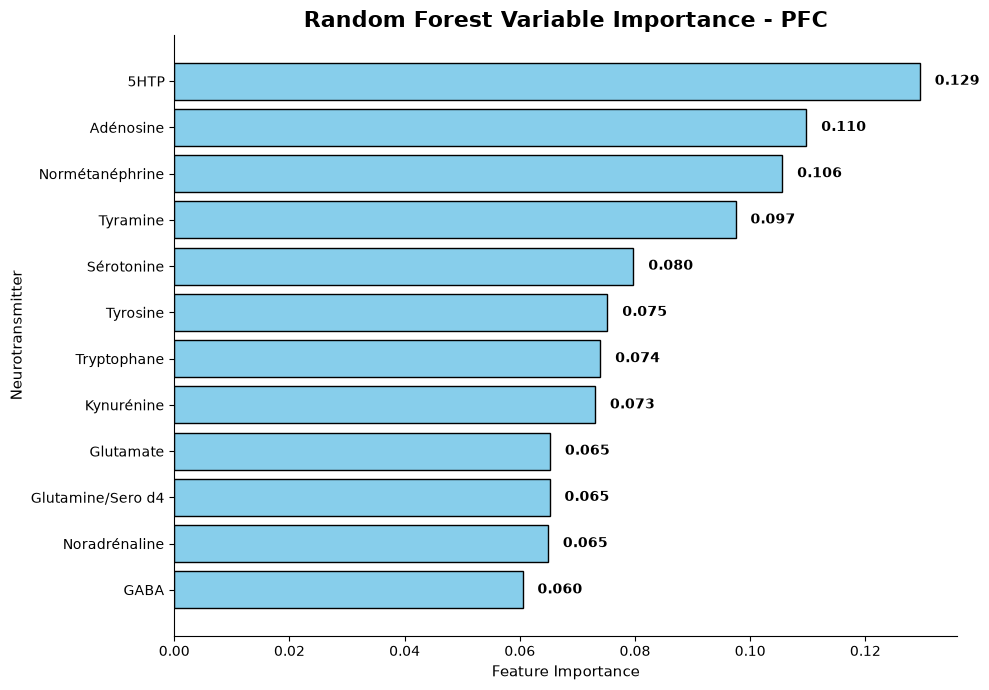

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort for horizontal bar order
rf_plot = rf_importance.sort_values(
    "Importance",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    rf_plot["NT"],
    rf_plot["Importance"],
    color="skyblue",
    edgecolor="black"
)

# Title and labels
ax.set_title(
    "Random Forest Variable Importance - PFC",
    fontsize=16,
    fontweight="semibold"
)

ax.set_xlabel(
    "Feature Importance",
    fontsize=11
)

ax.set_ylabel(
    "Neurotransmitter",
    fontsize=11
)


# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add importance values
offset = rf_plot["Importance"].max() * 0.02

for bar, value in zip(bars, rf_plot["Importance"]):
    ax.text(
        value + offset,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

<span style="font-weight: bold;"> Random Forest SHAP Analysis
SHAP (SHapley Additive exPlanations) was used to investigate how individual neurotransmitters contributed to the Random Forest predictions.
SHAP values quantify the contribution of each feature to the model output.   
Positive SHAP values indicate that a neurotransmitter pushes the prediction towards the LBN class, while negative values indicate a contribution towards the CONT class. 
The SHAP summary plot provides both the overall importance of each neurotransmitter and the direction of its effect

c:\Users\lydia\Downloads\RE_  Multivariate analyses for the NTS\.NTS\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


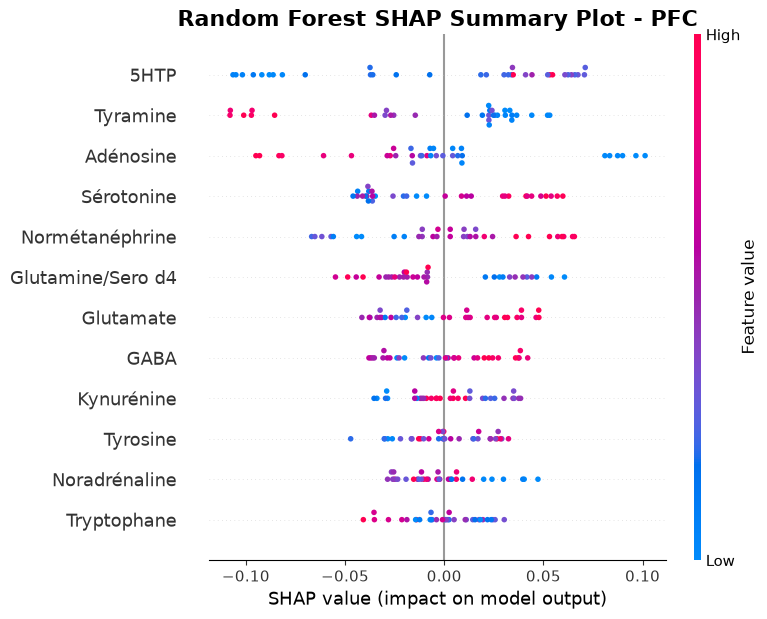

In [96]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

# Impute missing values
X_imp = rf_pipe.named_steps["imputer"].transform(X_juv_pfc_log)

X_imp = pd.DataFrame(
    X_imp,
    columns=X_juv_pfc_log.columns
)

# Extract tuned RF
rf = rf_pipe.named_steps["rf"]

# SHAP
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_imp)

# Binary classification
shap_class1 = shap_values[:, :, 1]

# Plot
shap.summary_plot(
    shap_class1,
    X_imp,
    show=False
)

plt.title("Random Forest SHAP Summary Plot - PFC", fontsize=16, fontweight="semibold")
plt.tight_layout()
plt.show()

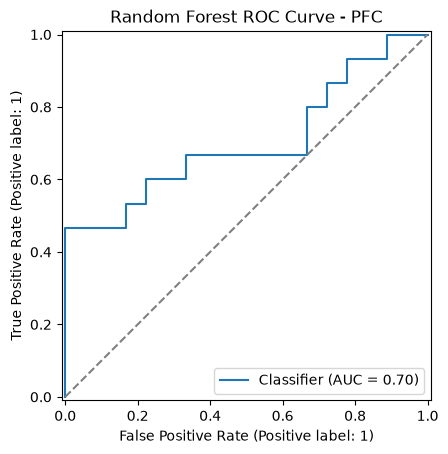

In [97]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    rf_pipe,
    X_juv_pfc_log,
    Y_juv_pfc,
    cv=cv,
    method="predict_proba"
)[:, 1]

RocCurveDisplay.from_predictions(
    Y_juv_pfc,
    y_prob
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)
plt.title("Random Forest ROC Curve - PFC")
plt.show()

In [98]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

rf_boot = pd.DataFrame(
    columns=X_juv_pfc_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_juv_pfc_log,
        Y_juv_pfc,
        replace=True,
        random_state=i
    )

    # Fit Random Forest
    rf_pipe.fit(
        X_boot,
        Y_boot
    )

    # Save feature importances
    rf_boot.loc[i] = rf_pipe.named_steps["rf"].feature_importances_

In [99]:
rf_summary = pd.DataFrame({
    "Mean": rf_boot.mean(),
    "Lower95": rf_boot.quantile(0.025),
    "Upper95": rf_boot.quantile(0.975)
})

rf_summary = rf_summary.sort_values(
    "Mean",
    ascending=False
)

print(rf_summary)

                       Mean   Lower95   Upper95
5HTP               0.120233  0.040702  0.246167
Adénosine          0.103592  0.040779  0.196283
Tyramine           0.100760  0.032005  0.212075
Normétanéphrine    0.082709  0.037220  0.170295
GABA               0.082635  0.035582  0.168335
Sérotonine         0.081473  0.034471  0.171068
Glutamine/Sero d4  0.078998  0.033461  0.166538
Tyrosine           0.072391  0.036643  0.137222
Noradrénaline      0.070127  0.030317  0.129767
Glutamate          0.070054  0.028519  0.143516
Tryptophane        0.069883  0.031807  0.136386
Kynurénine         0.067145  0.030006  0.136182


---

#### For the HIP

In [100]:
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(
        n_estimators=200, #Number of trees.
        max_depth=2, #Each tree can only make 2 splits.
        min_samples_leaf=2, #Minimum animals at the end of a branch.
        min_samples_split=4, #Minimum animals to consider a split.
        max_features="sqrt", #Number of features to consider at each split. Random Forest does NOT examine all variables.
        #If every tree always sees all NTs:become very similar. The forest loses diversity. Random feature selection creates more independent trees.
        class_weight="balanced", #Balance the classes.
        random_state=42 #Fixes randomness.
        ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

scores = cross_val_score(
    rf_pipe,
    X_juv_hip_log,
    Y_juv_hip,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("===== Random Forest =====")
print("Fold AUCs:", np.round(rf_scores, 3))
print(f"Mean AUC = {rf_scores.mean():.3f}")
print(f"SD = {rf_scores.std():.3f}")

===== Random Forest =====
Fold AUCs: [0.417 0.833 1.    0.778 0.667 0.417 0.667 0.5   0.444 0.778 0.583 0.75
 0.917 0.444 0.444 0.583 1.    0.167 0.778 1.    0.667 0.5   0.75  0.778
 0.889 0.583 0.417 0.833 0.889 0.778 0.5   0.917 0.75  1.    1.    0.917
 0.417 0.75  0.444 0.667 0.75  0.75  0.5   0.667 0.889 0.417 0.667 0.75
 0.333 1.    0.583 0.583 0.083 0.889 0.667 0.583 0.833 0.333 0.556 0.333
 1.    0.75  0.333 0.556 0.778 0.583 0.583 0.5   0.889 0.778 0.75  0.75
 0.5   0.889 0.444 0.75  0.667 0.75  0.667 0.667 0.417 0.333 0.583 0.556
 0.778 0.333 0.25  0.667 0.778 0.222 0.167 0.667 0.667 0.667 0.889 0.333
 0.25  0.333 0.444 0.889]
Mean AUC = 0.636
SD = 0.218


<span style="font-weight: bold;"> The Random Forest model achieved a mean ROC-AUC of **0.636 ± 0.218** across 100 repeated stratified cross-validation folds. This indicates that the model performs slightly better than random guessing (AUC = 0.5) The large standard deviation shows that model performance varied considerably between cross-validation splits.  

<span style="font-weight: bold;"> Some folds showed strong discrimination (AUC close to 1.0), while others showed poor performance (AUC below 0.5).This suggests that the model is unstable and that its predictive ability should be interpreted with caution.

In [101]:
rf_pipe.fit(X_juv_hip_log, Y_juv_hip)

rf = rf_pipe.named_steps["rf"]

rf_importance = pd.DataFrame({
    "NT": X_juv_hip_log.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print(rf_importance)

                   NT  Importance
0   Glutamine/Sero d4    0.174340
1                5HTP    0.151314
2                GABA    0.139811
3           Glutamate    0.110836
4            Tyrosine    0.104789
5         Tryptophane    0.071219
6     Normétanéphrine    0.070688
7          Kynurénine    0.054224
8       Noradrénaline    0.037883
9           Adénosine    0.032704
10           Tyramine    0.031325
11         Sérotonine    0.020868


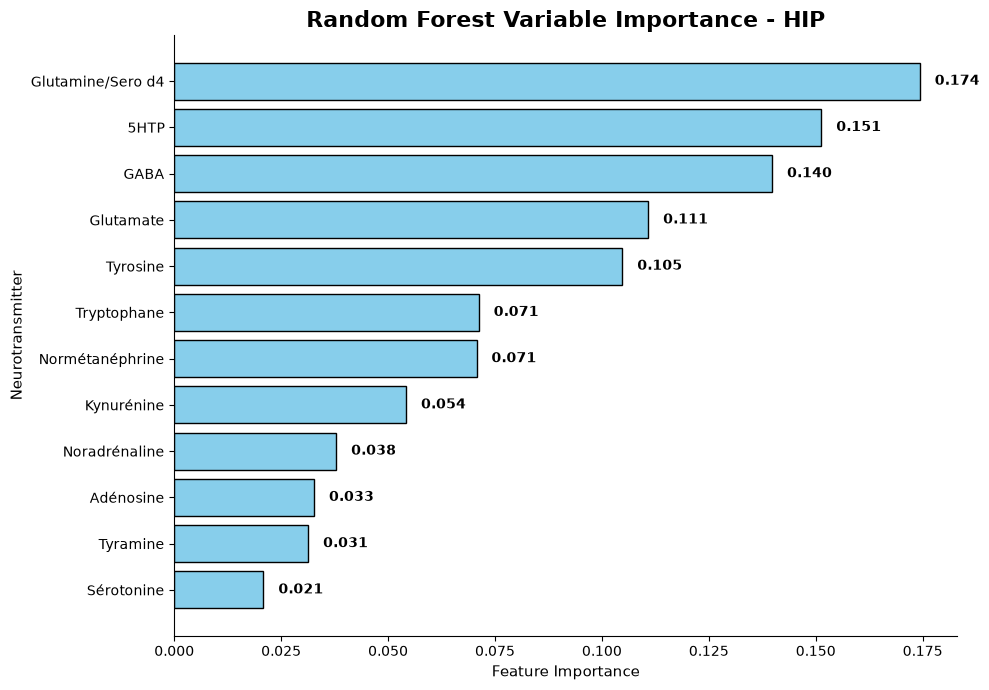

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort for horizontal bar order
rf_plot = rf_importance.sort_values(
    "Importance",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    rf_plot["NT"],
    rf_plot["Importance"],
    color="skyblue",
    edgecolor="black"
)

# Title and labels
ax.set_title(
    "Random Forest Variable Importance - HIP",
    fontsize=16,
    fontweight="semibold"
)

ax.set_xlabel(
    "Feature Importance",
    fontsize=11
)

ax.set_ylabel(
    "Neurotransmitter",
    fontsize=11
)


# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add importance values
offset = rf_plot["Importance"].max() * 0.02

for bar, value in zip(bars, rf_plot["Importance"]):
    ax.text(
        value + offset,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

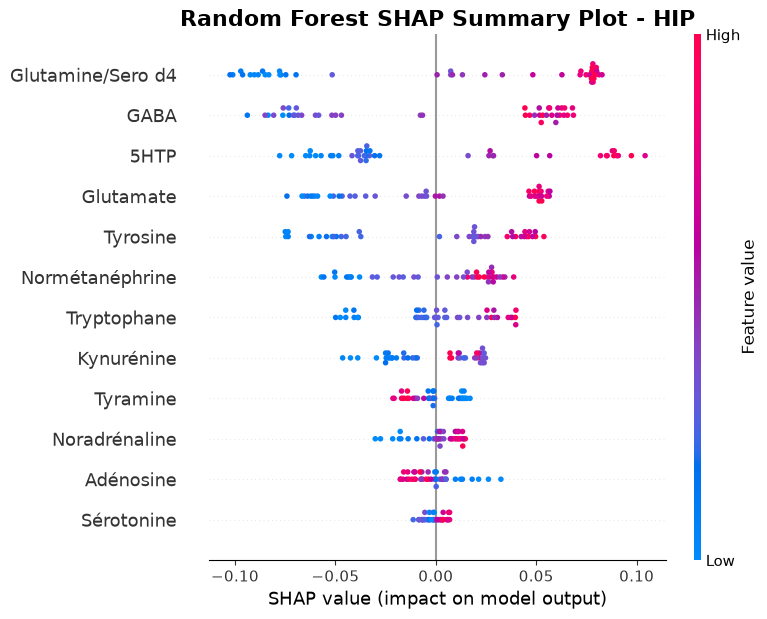

In [103]:
import pandas as pd
import shap
import matplotlib.pyplot as plt


# Impute missing values
X_imp = rf_pipe.named_steps["imputer"].transform(
    X_juv_hip_log
)

X_imp = pd.DataFrame(
    X_imp,
    columns=X_juv_hip_log.columns
)

# Extract tuned RF
rf = rf_pipe.named_steps["rf"]

# SHAP
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_imp)

# Binary classification
shap_class1 = shap_values[:, :, 1]

# Plot
shap.summary_plot(
    shap_class1,
    X_imp,
    show=False
)

plt.title("Random Forest SHAP Summary Plot - HIP", fontsize=16, fontweight="semibold")
plt.tight_layout()
plt.show()

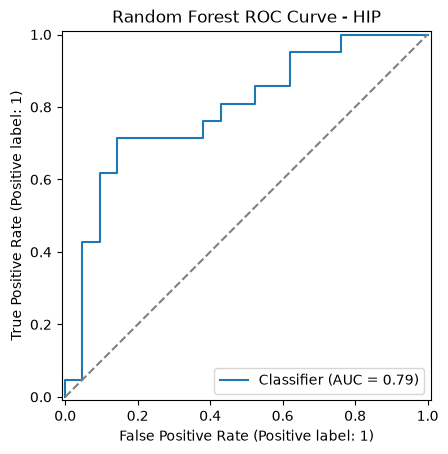

In [104]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    rf_pipe,
    X_juv_hip_log,
    Y_juv_hip,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_juv_hip,
    y_prob
)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Random Forest ROC Curve - HIP")
plt.show()

In [105]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

rf_boot = pd.DataFrame(
    columns=X_juv_hip_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_juv_hip_log,
        Y_juv_hip,
        replace=True,
        random_state=i
    )

    # Fit Random Forest
    rf_pipe.fit(
        X_boot,
        Y_boot
    )

    # Save feature importances
    rf_boot.loc[i] = rf_pipe.named_steps["rf"].feature_importances_

In [106]:
rf_summary = pd.DataFrame({
    "Mean": rf_boot.mean(),
    "Lower95": rf_boot.quantile(0.025),
    "Upper95": rf_boot.quantile(0.975)
})

rf_summary = rf_summary.sort_values(
    "Mean",
    ascending=False
)

print(rf_summary)

                       Mean   Lower95   Upper95
GABA               0.141751  0.042274  0.264389
Glutamine/Sero d4  0.137415  0.041748  0.259653
5HTP               0.131363  0.040708  0.234130
Tyrosine           0.110281  0.028450  0.220484
Glutamate          0.107348  0.033674  0.196584
Tryptophane        0.079444  0.017373  0.188891
Normétanéphrine    0.065210  0.012652  0.168756
Kynurénine         0.059585  0.015048  0.159408
Noradrénaline      0.046539  0.013237  0.113949
Adénosine          0.046213  0.012847  0.114937
Tyramine           0.040439  0.008189  0.116225
Sérotonine         0.034412  0.013932  0.076870


---

#### For the STR

In [107]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
import numpy as np

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        max_depth=3,
        min_samples_leaf=2,
        min_samples_split=4,
        class_weight="balanced",
        max_features="sqrt",
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

scores = cross_val_score(
    rf_pipe,
    X_juv_str_log,
    Y_juv_str,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)
print("===== Random Forest =====")
print("Fold AUCs:", np.round(rf_scores, 3))
print(f"Mean AUC = {rf_scores.mean():.3f}")
print(f"SD = {rf_scores.std():.3f}")

===== Random Forest =====
Fold AUCs: [0.417 0.833 1.    0.778 0.667 0.417 0.667 0.5   0.444 0.778 0.583 0.75
 0.917 0.444 0.444 0.583 1.    0.167 0.778 1.    0.667 0.5   0.75  0.778
 0.889 0.583 0.417 0.833 0.889 0.778 0.5   0.917 0.75  1.    1.    0.917
 0.417 0.75  0.444 0.667 0.75  0.75  0.5   0.667 0.889 0.417 0.667 0.75
 0.333 1.    0.583 0.583 0.083 0.889 0.667 0.583 0.833 0.333 0.556 0.333
 1.    0.75  0.333 0.556 0.778 0.583 0.583 0.5   0.889 0.778 0.75  0.75
 0.5   0.889 0.444 0.75  0.667 0.75  0.667 0.667 0.417 0.333 0.583 0.556
 0.778 0.333 0.25  0.667 0.778 0.222 0.167 0.667 0.667 0.667 0.889 0.333
 0.25  0.333 0.444 0.889]
Mean AUC = 0.636
SD = 0.218


<span style="font-weight: bold;">The Random Forest model achieved a mean ROC-AUC of **0.636 ± 0.218** across 100 repeated stratified cross-validation folds. This suggests that the model has a moderate ability to distinguish between the two classes and performs better than random guessing (AUC = 0.5).

<span style="font-weight: bold;"> However, the relatively large standard deviation indicates  variability in performance across different cross-validation splits. Some folds showed strong discrimination (AUC close to 1.0), while others showed poor performance (AUC below 0.5). This variability suggests that the model is sensitive to the specific samples included in each split, and its predictive performance should therefore be interpreted with caution.

In [108]:
rf_pipe.fit(X_juv_str_log, Y_juv_str)

rf = rf_pipe.named_steps["rf"]

# Variable importance
rf_importance = pd.DataFrame({
    "NT": X_juv_str_log.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print(rf_importance)

                   NT  Importance
0           Glutamate    0.264496
1       Noradrénaline    0.113530
2                5HTP    0.096959
3   Glutamine/Sero d4    0.088855
4            Tyramine    0.077442
5            Tyrosine    0.072598
6     Normétanéphrine    0.055459
7          Kynurénine    0.055167
8         Tryptophane    0.045979
9                GABA    0.045871
10          Adénosine    0.043880
11         Sérotonine    0.039763


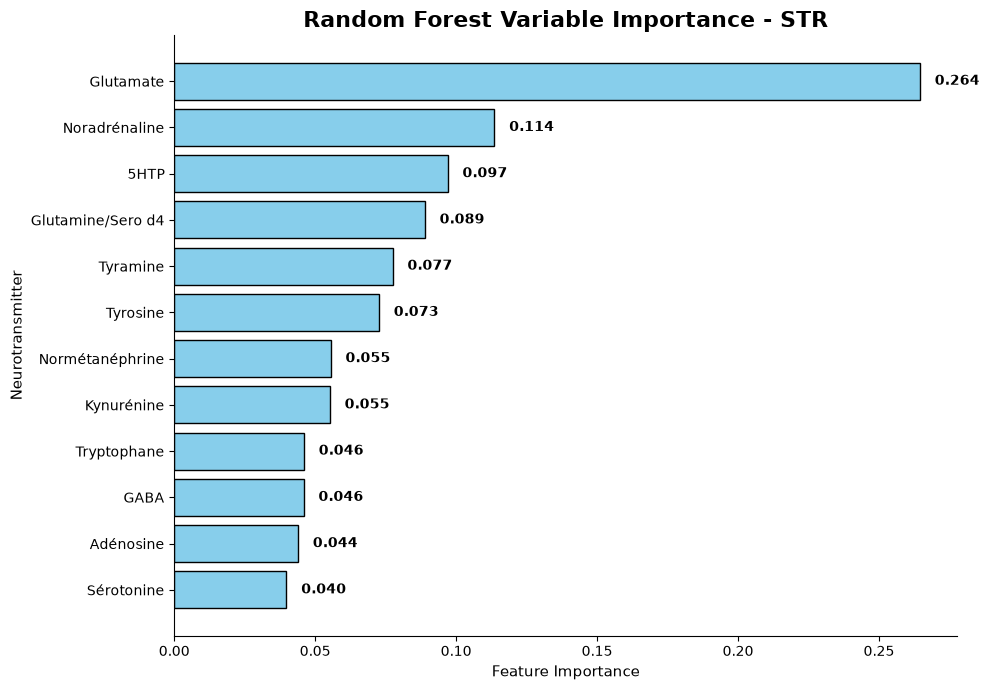

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort for horizontal bar order
rf_plot = rf_importance.sort_values(
    "Importance",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    rf_plot["NT"],
    rf_plot["Importance"],
    color="skyblue",
    edgecolor="black"
)

# Title and labels
ax.set_title(
    "Random Forest Variable Importance - STR",
    fontsize=16,
    fontweight="semibold"
)

ax.set_xlabel(
    "Feature Importance",
    fontsize=11
)

ax.set_ylabel(
    "Neurotransmitter",
    fontsize=11
)


# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add importance values
offset = rf_plot["Importance"].max() * 0.02

for bar, value in zip(bars, rf_plot["Importance"]):
    ax.text(
        value + offset,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

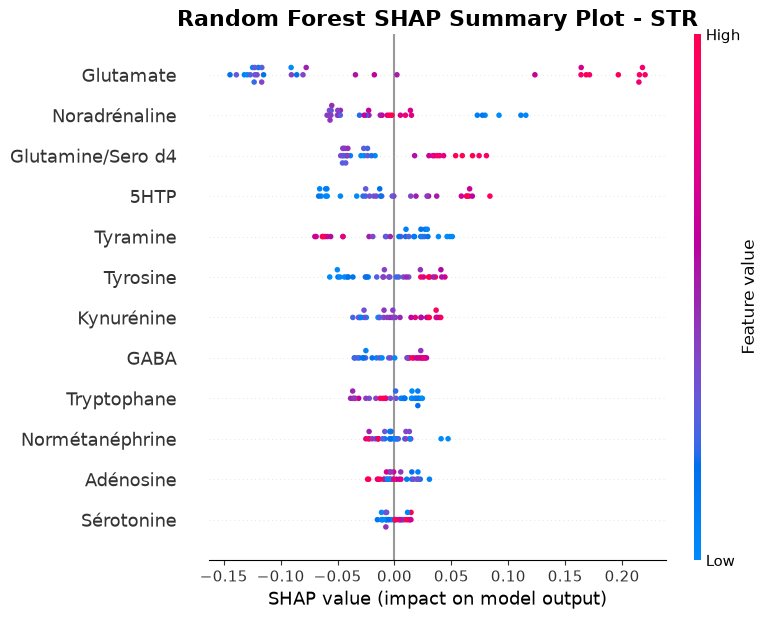

In [110]:
import pandas as pd
import shap
import matplotlib.pyplot as plt


# Impute missing values
X_imp = rf_pipe.named_steps["imputer"].transform(
    X_juv_str_log
)

X_imp = pd.DataFrame(
    X_imp,
    columns=X_juv_str_log.columns
)

# Extract tuned RF
rf = rf_pipe.named_steps["rf"]

# SHAP
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_imp)

# Binary classification
shap_class1 = shap_values[:, :, 1]

# Plot
shap.summary_plot(
    shap_class1,
    X_imp,
    show=False
)

plt.title("Random Forest SHAP Summary Plot - STR", fontsize=16, fontweight="semibold")
plt.tight_layout()
plt.show()

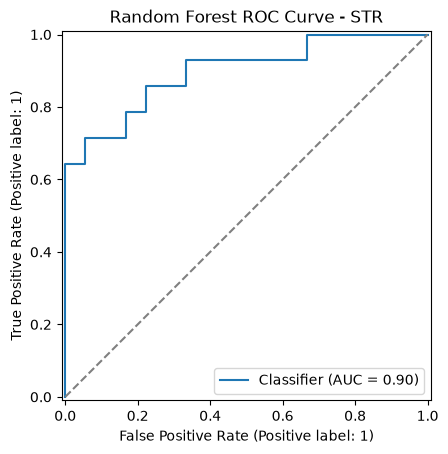

In [111]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    rf_pipe,
    X_juv_str_log,
    Y_juv_str,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_juv_str,
    y_prob
)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Random Forest ROC Curve - STR")
plt.show()

In [112]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

rf_boot = pd.DataFrame(
    columns=X_juv_str_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_juv_str_log,
        Y_juv_str,
        replace=True,
        random_state=i
    )

    # Fit Random Forest
    rf_pipe.fit(
        X_boot,
        Y_boot
    )

    # Save feature importances
    rf_boot.loc[i] = rf_pipe.named_steps["rf"].feature_importances_

In [113]:
rf_summary = pd.DataFrame({
    "Mean": rf_boot.mean(),
    "Lower95": rf_boot.quantile(0.025),
    "Upper95": rf_boot.quantile(0.975)
})

rf_summary = rf_summary.sort_values(
    "Mean",
    ascending=False
)

print(rf_summary)

                       Mean   Lower95   Upper95
Glutamate          0.219189  0.110671  0.315877
Noradrénaline      0.113518  0.041334  0.219441
5HTP               0.102960  0.032731  0.221996
Glutamine/Sero d4  0.090263  0.028759  0.192606
Tyrosine           0.081134  0.027834  0.175229
Tyramine           0.075161  0.021887  0.178003
Kynurénine         0.066311  0.022397  0.164743
GABA               0.057063  0.018439  0.137758
Normétanéphrine    0.053688  0.019688  0.107824
Adénosine          0.048522  0.019218  0.113240
Tryptophane        0.046406  0.016583  0.105506
Sérotonine         0.045787  0.019442  0.101296


----
#### Code supplementary for the Random Forest analysis

Here below is the code used to define what the correct value for each hyperparameter is for the Random Forest analysis. The code was used to find the best hyperparameters for the Random Forest model using GridSearchCV. The hyperparameters tuned include the number of trees in the forest (n_estimators), the maximum depth of each tree (max_depth), and the minimum number of samples required to split a node (min_samples_split). The grid search evaluates all combinations of these hyperparameters using cross-validation to identify the combination that yields the best performance based on a specified scoring metric (e.g., accuracy, ROC-AUC).

code supp

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
import numpy as np

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [2, 3],
    "rf__min_samples_leaf": [2, 4],
    "rf__min_samples_split": [4, 8]
}

inner_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

grid = GridSearchCV(
    rf_pipe,
    param_grid,
    cv=inner_cv,
    scoring="roc_auc",
    n_jobs=-1
)

outer_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

scores = cross_val_score(
    grid,
    X_juv_pfc_log,      # change for HIP or STR
    Y_juv_pfc,
    cv=outer_cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("===== Tuned Random Forest =====")
print(f"Mean AUC = {scores.mean():.3f}")
print(f"SD = {scores.std():.3f}")